In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import statsmodels.api as sm
from scipy.stats import scoreatpercentile, percentileofscore
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from matplotlib.patches import Rectangle

In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))

def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])

In [3]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [4]:
# old_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# old_groundtruth_test_water_ids = old_groundtruth[old_groundtruth.target.isin(['RnaseP']) & (old_groundtruth.split == 'test') & (old_groundtruth.sample_type == 'Negative Control (qPCR)')].sample_id.unique()
# # new_groundtruth_test_water_ids = groundtruth_df[(groundtruth_df.split == 'test') & (groundtruth_df.sample_type == 'Negative Control (qPCR)')].sample_id.unique()
# new_groundtruth_test_water_ids = groundtruth_df[(groundtruth_df.sample_type == 'Negative Control (qPCR)')].sample_id.unique()

# [i for i in old_groundtruth_test_water_ids if i in new_groundtruth_test_water_ids]

In [5]:
# water_well_ids = ['S624960', 'S993281', 'S1122933', 'S897698', 
#                   'S1262658', 'S1168204', 'S184660', 'S1270893']
water_well_ids = ['S1177561',
 'S1127015',
 'S626602',
 'S626604',
 'S1168204',
 'S1168205',
 'S1270893',
 'S1174654',]
# color_map = {'igi': 'mediumorchid', #'#008080',
#              'fusion': '#ffa500',
#              'qpcr':'#00ff00',
#              'deepnet': '#0000ff',
#              'humanbased': '#ff1493'
#              }

color_map = {'igi': '#0b4479', #'#008080',
             'fusion': '#ffbe4f',
             'qpcr':'#6bd2db',
             'deepnet': '#0ea7b5',
             'humanbased': '#ff1493',
             'achievable': '#4682b4'
             }

linestyle_map = {'fusion': 'dashed',
                 'qpcr': (0,(3,5,1,5,1,5)),
                 'deepnet': 'dotted',
                 'igi': (0,(3,1,1,1))}

##### read groundtruth data

In [6]:
known_df = pd.read_csv(os.path.join(old_data_dir, 'known_dilution_data.csv'))
karlen_df = pd.read_csv(os.path.join(old_data_dir, 'qpcr_karlen.csv'))
karlen_df['groundtruth_label'] = 1
karlen_df['curve_idx'] = karlen_df.curve_idx + '_' + karlen_df.data_set
karlen_df['inv_dilution_fold'] = 1/karlen_df.dilution_fold
chip60_df = pd.read_csv(os.path.join(old_data_dir, 'chipPCR_C60amp.csv'))
chip60_df['groundtruth_label'] = 1*(chip60_df.dilution != 0)


curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))
thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


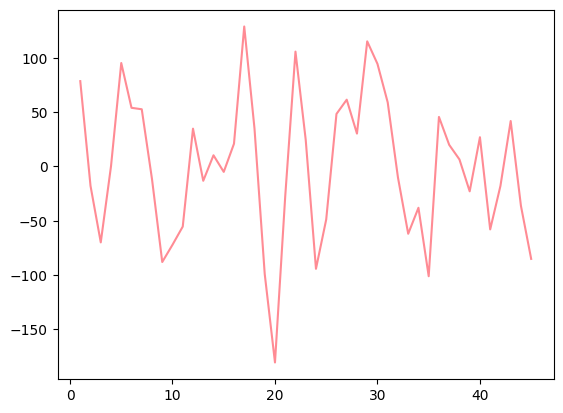

In [7]:
plt.plot(known_df[(known_df['well_position'] == 'O23') & (known_df.target == 'RnaseP')].cycle_no, 
         known_df[(known_df['well_position'] == 'O23') & (known_df.target == 'RnaseP')].drn, color='#ff8b94')

In [26]:
plt.plot(known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].cycle_no, 
         known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].drn, color='#ff8b94')
plt.plot(known_df[(known_df['well_position'] == 'A3') & (known_df.target == 'N gene')].cycle_no, 
         known_df[(known_df['well_position'] == 'A3') & (known_df.target == 'N gene')].drn, color='#ffaaa5')
plt.plot(known_df[(known_df['well_position'] == 'A1') & (known_df.target == 'N gene')].cycle_no, 
         known_df[(known_df['well_position'] == 'A1') & (known_df.target == 'N gene')].drn, color='#ffd3b6')

# plt.vlines(x=32, ymin=0, ymax=628656.440, color='red', linestyle='dashed')

# plt.annotate(
#     '', xy=(32, 628656.440), xytext=(32, 7.5e4),  # Arrow from (4, sin(4)) to (5, sin(5))
#     arrowprops=dict(arrowstyle="->", color="red", lw=1, linestyle='dotted')
# )
# plt.text(32, 3e4, r"$C_t$", fontsize=12, color="black", ha="center", va="center")


# plt.annotate(
#     '', xy=(-1, 620000.440), xytext=(32, 620000.440),  # Arrow from (4, sin(4)) to (5, sin(5))
#     arrowprops=dict(arrowstyle="->", color="red", lw=1, linestyle='dotted')
# )
# plt.text(-3, 620000.440, r"$F_n$", fontsize=12, color="black", ha="center", va="center")
plt.xlabel('Cycle Number')
plt.ylabel('Fluorescence')



Text(-3.902777777777784, 0.5, 'Fluorescence')

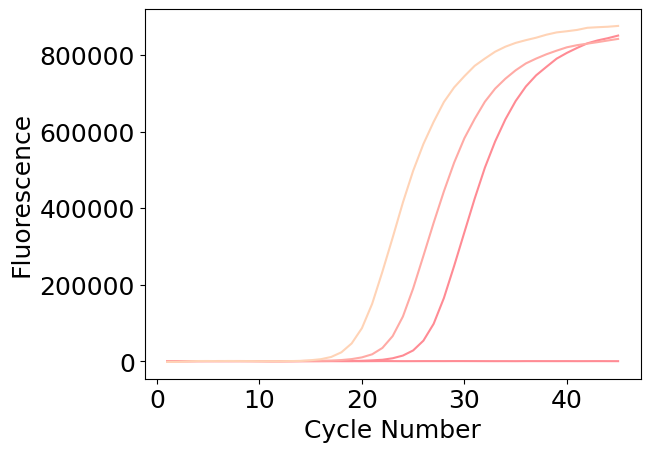

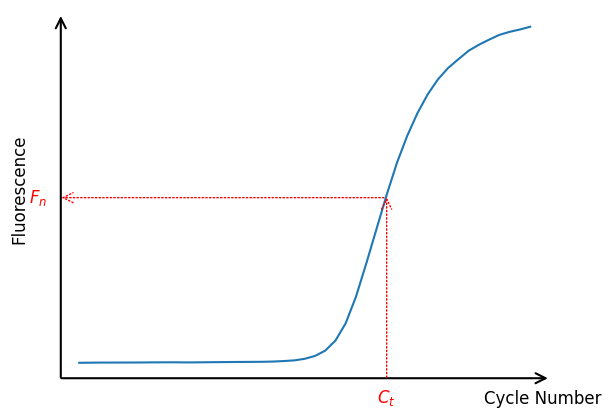

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

# Plot the function
ax.plot(known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].cycle_no, known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].Fn)

# Remove default spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Add arrowed x and y axes starting from the bottom-left (0,0)
ax.annotate('', xy=(47, 8.e4), xytext=(-1, 8.e4), arrowprops=dict(arrowstyle="->", linewidth=1.5))  # X-axis
ax.annotate('', xy=(-.8, 1.01e6), xytext=(-.8, 7.5e4), arrowprops=dict(arrowstyle="->", linewidth=1.5))  # Y-axis

# Add labels at the end of the arrows
ax.text(52, 5.e4, "Cycle Number", fontsize=12, ha="right", va="top")  # X label
ax.text(-4, 7e5, "Fluorescence", fontsize=12, ha="right", va="top", rotation=90)  # Y label

ax.annotate(
    '', xy=(31, 547333.600), xytext=(31, 7.5e4),  # Arrow from (4, sin(4)) to (5, sin(5))
    arrowprops=dict(arrowstyle="->", color="red", lw=1, linestyle='dotted')
)
ax.text(31, 3e4, r"$C_t$", fontsize=12, color="red", ha="center", va="center")
ax.annotate(
    '', xy=(-1, 540000.600), xytext=(31, 540000.600),  # Arrow from (4, sin(4)) to (5, sin(5))
    arrowprops=dict(arrowstyle="->", color="red", lw=1, linestyle='dotted')
)
ax.text(-3, 540000.440, r"$F_n$", fontsize=12, color="red", ha="center", va="center")

# Hide tick marks
ax.set_xticks([])
ax.set_yticks([])

plt.show()



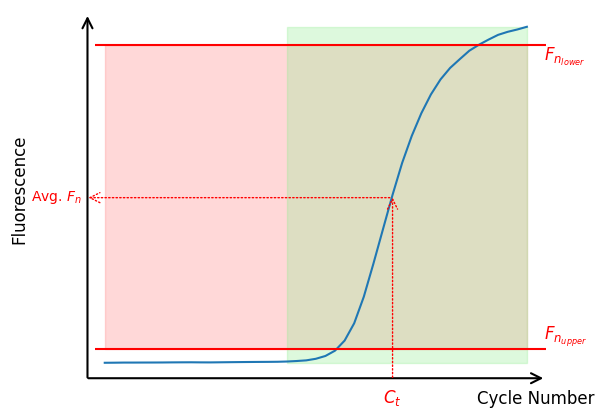

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

# Plot the function
ax.plot(known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].cycle_no, 
        known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].Fn)

# Remove default spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Add arrowed x and y axes starting from the bottom-left (0,0)
ax.annotate('', xy=(47, 8.e4), xytext=(-1, 8.e4), arrowprops=dict(arrowstyle="->", linewidth=1.5))  # X-axis
ax.annotate('', xy=(-.8, 1.01e6), xytext=(-.8, 7.5e4), arrowprops=dict(arrowstyle="->", linewidth=1.5))  # Y-axis

# Add labels at the end of the arrows
ax.text(52, 5.e4, "Cycle Number", fontsize=12, ha="right", va="top")  # X label
ax.text(-7, 7e5, "Fluorescence", fontsize=12, ha="right", va="top", rotation=90)  # Y label

ax.annotate(
    '', xy=(31, 547333.600), xytext=(31, 7.5e4),  # Arrow from (4, sin(4)) to (5, sin(5))
    arrowprops=dict(arrowstyle="->", color="red", lw=1, linestyle='dotted')
)
ax.text(31, 3e4, r"$C_t$", fontsize=12, color="red", ha="center", va="center")
ax.annotate(
    '', xy=(-1, 540000.600), xytext=(31, 540000.600),  # Arrow from (4, sin(4)) to (5, sin(5))
    arrowprops=dict(arrowstyle="->", color="red", lw=1, linestyle='dotted')
)
ax.text(-4, 540000.440, r"Avg. $F_n$", fontsize=10, color="red", ha="center", va="center")

ax.fill_between(known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].cycle_no, 
                 620000.440*0.25, 620000.440*1.5, color="#ff8080", alpha=0.3)
ax.hlines(y=620000.440*0.25, xmin=0, xmax=47, color="red")
ax.hlines(y=620000.440*1.5, xmin=0, xmax=47, color="red")
ax.text(49, 620000.440*0.3, r"$F_{n_{upper}}$", fontsize=12, color="red", ha="center", va="center")
ax.text(49, 620000.440*1.45, r"$F_{n_{lower}}$", fontsize=12, color="red", ha="center", va="center")


ax.fill_betweenx(known_df[(known_df['well_position'] == 'A5') & (known_df.target == 'N gene')].Fn, 
                 20,45, color="#90EE90", alpha=0.3)

# Hide tick marks
ax.set_xticks([])
ax.set_yticks([])

plt.show()



##### read prediction data : fusion

In [8]:
## old data

# known_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_known_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_karlen_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_chip60_pred_df.csv'))

known_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_known_pred_df.csv'))
karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_karlen_pred_df.csv'))
chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_chip60_pred_df.csv'))

# known_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_known_pred.csv'))
# chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))
# test_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))


In [9]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_test_pred_df.csv'))
test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'fusion_vit_delta64_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))

test_pred = (test_pred
             .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
                    on='curve_idx')
             .merge(groundtruth_df.loc[groundtruth_df.split == 'test', 
                                       ['curve_idx','sample_id','target','igi_call','groundtruth']],
                    on='curve_idx')
             )

# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# test_pred = test_pred[test_pred.split == 'test']
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))

# test_pred = (test_pred
#              .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
#                     on='curve_idx')
#              .merge(groundtruth_df
#                     .loc[groundtruth_df.cycle_no == 40,
#                          ['curve_idx','sample_id','target','igi_call','groundtruth']],
#                     on='curve_idx')
#              )

test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

##### read prediction data : qpcR

In [10]:
chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))

karlen_qpcr_pred = pd.DataFrame()
for i in range(1,4):
    df = pd.read_csv(os.path.join(old_modeloutput_dir, f'qpcr_karlen{i}_pred.csv'))
    df['curve_idx'] = df['curve_idx'] + f'_karlen{i}'
    karlen_qpcr_pred = pd.concat([karlen_qpcr_pred, df])
karlen_qpcr_pred = karlen_qpcr_pred.reset_index()

known_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_known_pred.csv'))


In [11]:
qpcr_known_test = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
qpcr_known_water = (qpcr_known_test[qpcr_known_test.split == 'test']
                   .merge(join_df.loc[(join_df.cycle_no == 1) & (join_df.sample_id.isin(water_well_ids)), ['curve_idx']],
                          on='curve_idx'))
qpcr_known_water['dilution_level'] = 0
qpcr_known_pred_df = pd.concat([(known_qpcr_pred
                      .merge(known_df.loc[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP'), ['curve_idx','dilution_level']], 
                             on='curve_idx')),
                                qpcr_known_water[['curve_idx','eff','groundtruth_label','prob','dilution_level']]])



##### read prediction data : qPCRdeepNet

In [12]:
chip60_deep_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_chip60_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
chip60_deep_pred = (chip60_deep_pred
                    .merge(chip60_df.loc[chip60_df['Index'] == 1, ['curve_idx','groundtruth_label']], 
                           left_on='id1', right_on='curve_idx'))
chip60_deep_pred['probability'] = chip60_deep_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

karlen_deep_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_karlen_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
karlen_deep_pred['curve_idx'] = karlen_deep_pred.id1 + '_' + karlen_deep_pred.id2
karlen_deep_pred = (karlen_deep_pred
                    .merge(karlen_df.loc[karlen_df.Cycles == 1, ['curve_idx','groundtruth_label']],
                           on='curve_idx'))
karlen_deep_pred['probability'] = karlen_deep_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

groundtruth_deep_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
water_deep_pred = (groundtruth_deep_pred
                   .merge(qpcr_known_water[['curve_idx','groundtruth_label','dilution_level']], left_on='id1', right_on='curve_idx'))

known_deep_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_known_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
known_deep_pred_df = pd.concat([(known_deep_pred
                   			.merge(qpcr_known_pred_df[['curve_idx','groundtruth_label','dilution_level']],
                             left_on='id1', right_on='curve_idx')),
                                water_deep_pred])
known_deep_pred_df['probability'] = known_deep_pred_df.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

### Fusion human based model

In [13]:
chip60_humanbased_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_chip_pred_df.csv'))

karlen_humanbased_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_karlen_pred_df.csv'))

groundtruth_humanbased_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_test_pred_df.csv'))
water_humanbased_pred = (groundtruth_humanbased_pred
                   .merge(qpcr_known_water[['curve_idx','dilution_level']], on='curve_idx'))

known_humanbased_pred = pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_known_pred_df.csv'))
known_humanbased_pred_df = pd.concat([(known_humanbased_pred
                   			.merge(qpcr_known_pred_df[['curve_idx','dilution_level']],
                             on='curve_idx')),
                                water_humanbased_pred])

In [14]:
# best_test_acc_thres = 0.529 # old seq
# best_test_acc_thres = 0.51 #image new
best_test_acc_thres = 0.566 # fusion
best_qpcr_test_acc_thres = 0.522 
best_deepnet_test_acc_thres = 0.87
best_humanbased_test_acc_thres = 0.01

water_output_df = (test_pred.loc[test_pred.sample_id.isin(water_well_ids),
                                ['curve_idx','sample_id','groundtruth_label','outputs','target','encoded_igi_call']]
                   .merge(qpcr_known_pred_df[['curve_idx','prob']], on='curve_idx')
                   .merge(known_deep_pred_df[['curve_idx','probability']], on='curve_idx')
                   .merge(known_humanbased_pred_df[['curve_idx','outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                   .rename(columns={'encoded_igi_call':'new_igi_call',
                                    'groundtruth_label':'groundtruth_target',
                                    'sample_id':'well_position'})
                   .reset_index())
water_output_df['dilution_level'] = 0
water_output_df['pred'] = 1*(water_output_df.outputs >= best_test_acc_thres)
water_output_df['qpcr_pred'] = 1*(water_output_df.prob >= best_qpcr_test_acc_thres)
water_output_df['deepnet_pred'] = 1*(water_output_df.probability >= best_deepnet_test_acc_thres)
water_output_df['humanbased_pred'] = 1*(water_output_df.human_prob >= best_humanbased_test_acc_thres)
print(water_output_df.shape)

(24, 15)


In [15]:
boxplot_known_df = known_df[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP')].copy()

boxplot_known_df['new_igi_call'] = 1*(boxplot_known_df.amp_status == 'Amp')
boxplot_known_df = (boxplot_known_df
                    .merge(known_pred, on='curve_idx')
                    .merge(qpcr_known_pred_df[['curve_idx','prob']], on='curve_idx')
                    .merge(known_deep_pred_df[['curve_idx','probability']], on='curve_idx')
                    .merge(known_humanbased_pred_df[['curve_idx','outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                    # .rename(columns={'groundtruth_label':'groundtruth_target'})
                    )
boxplot_known_df['pred'] = 1*(boxplot_known_df.outputs >= best_test_acc_thres)
boxplot_known_df['qpcr_pred'] = 1*(boxplot_known_df.prob >= best_qpcr_test_acc_thres)
boxplot_known_df['deepnet_pred'] = 1*(boxplot_known_df.probability >= best_deepnet_test_acc_thres)
boxplot_known_df['humanbased_pred'] = 1*(boxplot_known_df.human_prob >= best_humanbased_test_acc_thres)


In [16]:
known_df['sample_id'] = known_df.well_position + '_' + known_df.dilution_level.astype(str)
known_df['test_kit'] = 'LuNER'
known_df['dataset'] = 'known'
known_df['groundtruth_label'] = 1

water_df = join_df.loc[join_df.sample_id.isin(water_well_ids), ['sample_id','test_kit','well_position','curve_idx','target','cycle_no','amp_score','rn','drn','cq','threshold']].copy()
water_df['dataset'] = 'water'
water_df['groundtruth_label'] = 0

simulated_igi_df = pd.concat([known_df.loc[known_df.target != 'RnaseP', ['sample_id','test_kit','well_position','curve_idx','target','cycle_no','amp_score','rn','drn','cq','threshold','dataset','groundtruth_label']],
                              water_df[['sample_id','test_kit','well_position','curve_idx','target','cycle_no','amp_score','rn','drn','cq','threshold','dataset','groundtruth_label']]])
simulated_igi_df.groupby('sample_id').target.nunique().reset_index().sort_values('target', ascending=False)

,sample_id,target
103,S626604,3
102,S626602,3
101,S1270893,3
100,S1177561,3
99,S1174654,3
...,...,...
31,E23_1,2
30,E21_1000,2
29,E1_100000,2
28,E19_100000,2


In [17]:
thres_df = {'fpr':[], 'tpr': [], 'fnr':[], 'pos_pred': [], 'perc': [], 'cycle': []}

cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(30,41)},
                    'Thermo': np.arange(30,41)}
                    
fn_range = np.arange(-.9, 4, 0.05)

for perc in fn_range:
    for cycle in range(10):
        df = simulated_igi_df.copy()
        df['new_threshold'] = simulated_igi_df.threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        # if the sample is known dilution, control gene is always positive
        df.loc[(df.dataset == 'known') & (df.target == 'RnaseP'), 'new_igi_call'] = 1
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['tpr'].append(tp/(tp+fn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        thres_df['perc'].append(perc)
        thres_df['cycle'].append(cycle)
thres_df = pd.DataFrame(thres_df)
        

In [18]:
thres_df['youden'] = thres_df.tpr - thres_df.fpr
# thres_df.sort_values('youden', ascending=False).head(1)

simulated_igi_df['new_threshold'] = simulated_igi_df.threshold * (1 + thres_df.perc[thres_df.youden.idxmax()])
simulated_igi_df['if_pass'] = simulated_igi_df.drn >= simulated_igi_df.new_threshold
passed_ids = simulated_igi_df[simulated_igi_df.if_pass].curve_idx.unique()
simulated_igi_df['new_ct'] = np.Inf
simulated_igi_df.loc[simulated_igi_df.curve_idx.isin(passed_ids), 'new_ct'] = simulated_igi_df[simulated_igi_df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')


simulated_igi_df.loc[simulated_igi_df.test_kit == 'Thermo','simulated_new_igi_call'] = 1*(simulated_igi_df[simulated_igi_df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])

simulated_igi_df.loc[(simulated_igi_df.test_kit == 'LuNER') & (simulated_igi_df.target == 'RnaseP'), 'simulated_new_igi_call'] = 1*(simulated_igi_df[(simulated_igi_df.test_kit == 'LuNER') & (simulated_igi_df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
simulated_igi_df.loc[(simulated_igi_df.test_kit == 'LuNER') & (simulated_igi_df.target != 'RnaseP'), 'simulated_new_igi_call'] = 1*(simulated_igi_df[(simulated_igi_df.test_kit == 'LuNER') & (simulated_igi_df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])

# if the sample is known dilution, control gene is always positive
simulated_igi_df.loc[(simulated_igi_df.dataset == 'known') & (simulated_igi_df.target == 'RnaseP'), 'simulated_new_igi_call'] = 1

final_simulated_igi_df = simulated_igi_df[simulated_igi_df.cycle_no == 1].copy()

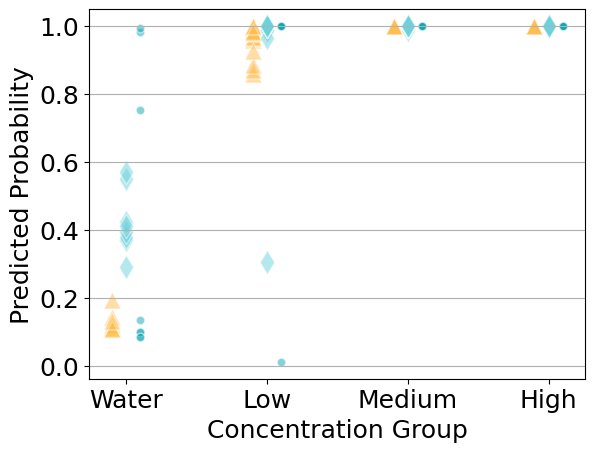

In [19]:
plt.rcParams.update({'font.size': 18})
color_dict = {'igi': '#0b4479', #'#008080',
             'fusion': '#ffbe4f',
             'qpcr':'#6bd2db',
             'deepnet': '#0ea7b5',
             'humanbased': '#ff1493',
             'achievable': '#4682b4'
             }
marker_dict = {'fusion': '^',
               'qpcr':'d',
               'deepnet':'.'}
boxplot_df = pd.concat([boxplot_known_df[['curve_idx','well_position','dilution_level','target','outputs','pred','new_igi_call','prob','qpcr_pred','probability','deepnet_pred','humanbased_pred']], 
                        water_output_df[['curve_idx','well_position','dilution_level','target','outputs','pred','new_igi_call','prob','qpcr_pred','probability','deepnet_pred','humanbased_pred']]], axis=0)
boxplot_df = boxplot_df.merge(final_simulated_igi_df[['curve_idx','simulated_new_igi_call']], on='curve_idx')
boxplot_df['dilution_group'] = 'Medium'
boxplot_df.loc[boxplot_df.dilution_level == 0, 'dilution_group'] = 'Water'
boxplot_df.loc[boxplot_df.dilution_level == 1, 'dilution_group'] = 'Low'
boxplot_df.loc[boxplot_df.dilution_level >= 100000, 'dilution_group'] = 'High'

boxplot_dilution_group_df = boxplot_df[['well_position','dilution_group','outputs','prob','probability']].groupby(['well_position','dilution_group']).agg('max').reset_index()
boxplot_dilution_group_df = pd.melt(boxplot_dilution_group_df, id_vars=['well_position','dilution_group'], var_name='Model', value_name='Prob')
boxplot_dilution_group_df['group_idx'] = boxplot_dilution_group_df.dilution_group.map({'Water': 0, 'Low': 1, 'Medium': 2, 'High': 3})
boxplot_dilution_group_df['xaxis_position'] = boxplot_dilution_group_df['group_idx'] + boxplot_dilution_group_df.Model.map({'outputs': -0.1, 'prob': 0, 'probability': 0.1})

sns.scatterplot(boxplot_dilution_group_df[boxplot_dilution_group_df.Model == 'outputs'], 
                x = 'xaxis_position', y='Prob', marker=marker_dict['fusion'],
                alpha=0.5, s=150, color=color_dict['fusion'])
sns.scatterplot(boxplot_dilution_group_df[boxplot_dilution_group_df.Model == 'prob'],
                x = 'xaxis_position', y='Prob', alpha=0.5, s=150, 
                marker=marker_dict['qpcr'], color=color_dict['qpcr'])
sns.scatterplot(boxplot_dilution_group_df[boxplot_dilution_group_df.Model == 'probability'], 
                x = 'xaxis_position', y='Prob', alpha=0.5, s=150, 
                marker=marker_dict['deepnet'], color=color_dict['deepnet'])

# plt.title('Boxplot of predicted probabilities across dilution levels')
# plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(ticks=[0, 1, 2, 3], labels=['Water', 'Low', 'Medium', 'High'], rotation=0)
plt.xlabel('Concentration Group')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
# plt.legend()

In [20]:
xlabels = [str(x) for x in sorted(boxplot_df.dilution_level.unique())]

spark_df = boxplot_df[['dilution_level','target','outputs']]
spark_df['x_numeric'] = spark_df.dilution_level.apply(lambda x: xlabels.index(str(x)))
spark_df['x_numeric'] = spark_df.x_numeric - 0.225 #+ np.random.uniform(-0.01, 0.01, size=len(spark_df.x_numeric))

qpcr_df = boxplot_df[['dilution_level','target','prob']]
qpcr_df['x_numeric'] = qpcr_df.dilution_level.apply(lambda x: xlabels.index(str(x)))
qpcr_df['x_numeric'] = qpcr_df.x_numeric - 0.075 #+ np.random.uniform(-0.01, 0.01, size=len(spark_df.x_numeric))

deepnet_df = boxplot_df[['dilution_level','target','probability']]
deepnet_df['x_numeric'] = deepnet_df.dilution_level.apply(lambda x: xlabels.index(str(x)))
deepnet_df['x_numeric'] = deepnet_df.x_numeric + 0.075 #+ np.random.uniform(-0.01, 0.01, size=len(spark_df.x_numeric))

best_achievable_df = boxplot_df[['dilution_level','target','simulated_new_igi_call']]
best_achievable_df['x_numeric'] = best_achievable_df.dilution_level.apply(lambda x: xlabels.index(str(x)))
best_achievable_df['x_numeric'] = best_achievable_df.x_numeric + 0.225 #+ np.random.uniform(-0.01, 0.01, size=len(spark_df.x_numeric))

/tmp/ipykernel_3866593/1654354917.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spark_df['x_numeric'] = spark_df.dilution_level.apply(lambda x: xlabels.index(str(x)))
/tmp/ipykernel_3866593/1654354917.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spark_df['x_numeric'] = spark_df.x_numeric - 0.225 #+ np.random.uniform(-0.01, 0.01, size=len(spark_df.x_numeric))
/tmp/ipykernel_3866593/1654354917.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [21]:
color_map = {'igi': 'mediumorchid', #'#008080',
             'fusion': '#ffa500',
             'qpcr':'#00ff00',
             'deepnet': '#0000ff',
             'humanbased': '#ff1493'
             }


/tmp/ipykernel_3866593/82903269.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


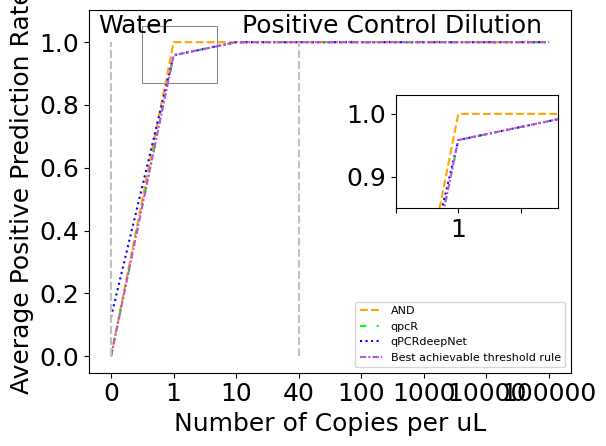

In [22]:

known_sampled_pred = (boxplot_df[boxplot_df.target.isin(['N gene','E gene'])]
                      .groupby(['dilution_level', 'well_position'])
                      .agg(sample_pred = ('pred', 'mean'),
                           sample_igi_call = ('new_igi_call', 'mean'),
                           sample_simulated_igi_call = ('simulated_new_igi_call', 'mean'),
                           sample_qpcr_pred = ('qpcr_pred','mean'),
                           sample_deepnet_pred = ('deepnet_pred','mean'),
                           sample_humanbased_pred = ('humanbased_pred','mean'),
                           )
                      .reset_index())
known_sampled_pred['sample_pred'] = 1*(known_sampled_pred.sample_pred >= 0.5)
known_sampled_pred['sample_igi_call'] = 1*(known_sampled_pred.sample_igi_call >= 0.5)
known_sampled_pred['sample_simulated_igi_call'] = 1*(known_sampled_pred.sample_simulated_igi_call >= 0.5)
known_sampled_pred['sample_qpcr_pred'] = 1*(known_sampled_pred.sample_qpcr_pred >= 0.5)
known_sampled_pred['sample_deepnet_pred'] = 1*(known_sampled_pred.sample_deepnet_pred >= 0.5)
known_sampled_pred['sample_humanbased_pred'] = 1*(known_sampled_pred.sample_humanbased_pred >= 0.5)

pos_known_pred = known_sampled_pred.groupby('dilution_level')[['sample_igi_call','sample_pred','sample_simulated_igi_call','sample_qpcr_pred','sample_deepnet_pred','sample_humanbased_pred']].apply(lambda x: x.sum()/len(x)).reset_index() #
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')

x_indices = range(pos_known_pred.dilution_level.nunique())

fig, ax = plt.subplots()

ax.plot(x_indices, pos_known_pred.sample_pred, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'))
# ax.scatter(x_indices, pos_known_pred.sample_pred, facecolor='none', edgecolor = color_map.get('fusion'), label='_nolegend_')

ax.plot(x_indices, pos_known_pred.sample_qpcr_pred, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'))
# ax.scatter(x_indices, pos_known_pred.sample_qpcr_pred, facecolor='none', edgecolor = color_map.get('qpcr'), marker='^', label='_nolegend_')

ax.plot(x_indices, pos_known_pred.sample_deepnet_pred, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'))
# ax.scatter(x_indices, pos_known_pred.sample_deepnet_pred, color = color_map.get('deepnet'), marker='x', label='_nolegend_')

ax.plot(x_indices, pos_known_pred.sample_simulated_igi_call, color=color_map.get('igi'), linestyle=linestyle_map.get('igi'))
# ax.scatter(x_indices, pos_known_pred.sample_simulated_igi_call, facecolor='none', edgecolors=color_map.get('igi'), s = 100, label='_nolegend_')

zoom_ax = zoomed_inset_axes(ax, zoom=2, bbox_to_anchor= (0.9, 0.6, 0.1, 0.2), bbox_transform=ax.transAxes)
zoom_ax.plot(x_indices, pos_known_pred.sample_pred, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'))
zoom_ax.plot(x_indices, pos_known_pred.sample_qpcr_pred, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'))
zoom_ax.plot(x_indices, pos_known_pred.sample_deepnet_pred, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'))
zoom_ax.plot(x_indices, pos_known_pred.sample_simulated_igi_call, color=color_map.get('igi'), linestyle=linestyle_map.get('igi'))

zoom_ax.set_xlim(0.5, 1.8)
zoom_ax.set_xticks([0.5, 1, 1.5], ['', '1', ''])
zoom_ax.set_ylim(0.85, 1.03)

zoom_region = Rectangle((0.5, 0.87), 1.2, 0.18, edgecolor="0.5", facecolor="none", linewidth=.7)
ax.add_patch(zoom_region)

ax.vlines([0, 3], 0, 1, linestyles='dashed', colors='silver')
ax.text(-0.2, 1.03, 'Water')
ax.text(2.1, 1.03, 'Positive Control Dilution')
ax.set_xticks(x_indices, pos_known_pred.dilution_level.unique())


ax.legend(labels=['AND','qpcR','qPCRdeepNet','Best achievable threshold rule'], fontsize=8)
# ax.title('Proportion of predicted positive samples in dilution level')
ax.set_xlabel('Number of Copies per uL')
ax.set_ylabel('Average Positive Prediction Rate')
# ax.grid(axis='y')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/known_sample_pred.png')

In [23]:

known_sampled_pred = (boxplot_df
                      .groupby(['dilution_level', 'well_position'])
                      .agg(sample_pred = ('pred', 'mean'),
                           sample_igi_call = ('new_igi_call', 'mean'),
                           sample_simulated_igi_call = ('simulated_new_igi_call', 'mean'),
                           sample_qpcr_pred = ('qpcr_pred','mean'),
                           sample_deepnet_pred = ('deepnet_pred','mean'),
                           sample_humanbased_pred = ('humanbased_pred','mean'),
                           )
                      .reset_index())
known_sampled_pred['sample_pred'] = 1*(known_sampled_pred.sample_pred >= 0.5)
known_sampled_pred['sample_igi_call'] = 1*(known_sampled_pred.sample_igi_call >= 0.5)
known_sampled_pred['sample_simulated_igi_call'] = 1*(known_sampled_pred.sample_simulated_igi_call >= 0.5)
known_sampled_pred['sample_qpcr_pred'] = 1*(known_sampled_pred.sample_qpcr_pred >= 0.5)
known_sampled_pred['sample_deepnet_pred'] = 1*(known_sampled_pred.sample_deepnet_pred >= 0.5)
known_sampled_pred['sample_humanbased_pred'] = 1*(known_sampled_pred.sample_humanbased_pred >= 0.5)

known_sampled_pred['truth'] = 1
known_sampled_pred.loc[known_sampled_pred.dilution_level == 0, 'truth'] = 0
known_sampled_pred['sample_accuracy'] = 1*(known_sampled_pred.sample_pred == known_sampled_pred.truth)
known_sampled_pred['sample_simulated_igi_accuracy'] = 1*(known_sampled_pred.sample_simulated_igi_call == known_sampled_pred.truth)
known_sampled_pred['sample_qpcr_accuracy'] = 1*(known_sampled_pred.sample_qpcr_pred == known_sampled_pred.truth)
known_sampled_pred['sample_deepnet_accuracy'] = 1*(known_sampled_pred.sample_deepnet_pred == known_sampled_pred.truth)

pos_known_pred = known_sampled_pred.groupby('dilution_level')[['sample_simulated_igi_accuracy','sample_accuracy','sample_qpcr_accuracy','sample_deepnet_accuracy']].apply(lambda x: x.sum()/len(x)).reset_index()
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')


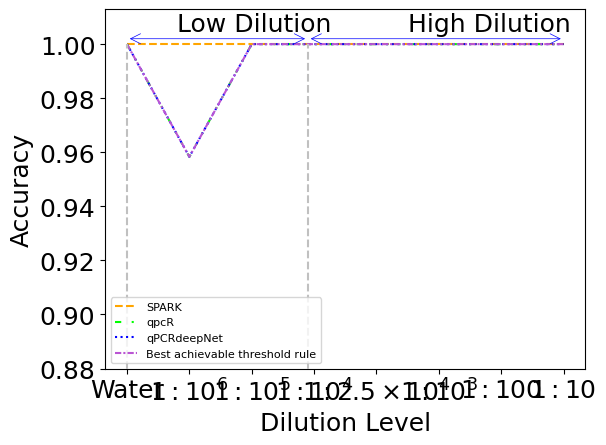

In [24]:

x_indices = range(pos_known_pred.dilution_level.nunique())

fig, ax = plt.subplots()

ax.plot(x_indices, pos_known_pred.sample_accuracy, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'))
# ax.scatter(x_indices, pos_known_pred.sample_pred, facecolor='none', edgecolor = color_map.get('fusion'), label='_nolegend_')

ax.plot(x_indices, pos_known_pred.sample_qpcr_accuracy, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'))
# ax.scatter(x_indices, pos_known_pred.sample_qpcr_pred, facecolor='none', edgecolor = color_map.get('qpcr'), marker='^', label='_nolegend_')

ax.plot(x_indices, pos_known_pred.sample_deepnet_accuracy, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'))
# ax.scatter(x_indices, pos_known_pred.sample_deepnet_pred, color = color_map.get('deepnet'), marker='x', label='_nolegend_')

ax.plot(x_indices, pos_known_pred.sample_simulated_igi_accuracy, color=color_map.get('igi'), linestyle=linestyle_map.get('igi'))
# ax.scatter(x_indices, pos_known_pred.sample_simulated_igi_call, facecolor='none', edgecolors=color_map.get('igi'), s = 100, label='_nolegend_')

# zoom_ax = zoomed_inset_axes(ax, zoom=2, bbox_to_anchor= (0.9, 0.6, 0.1, 0.2), bbox_transform=ax.transAxes)
# zoom_ax.plot(x_indices, pos_known_pred.sample_accuracy, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'))
# zoom_ax.plot(x_indices, pos_known_pred.sample_qpcr_accuracy, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'))
# zoom_ax.plot(x_indices, pos_known_pred.sample_deepnet_accuracy, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'))
# zoom_ax.plot(x_indices, pos_known_pred.sample_simulated_igi_accuracy, color=color_map.get('igi'), linestyle=linestyle_map.get('igi'))

# zoom_ax.set_xlim(0.9, 2.1)
# zoom_ax.set_xticks([1, 2], [r'1:$10^5$', r'1:$10^4$'])
# zoom_ax.set_ylim(0.85, 1.03)

# zoom_region = Rectangle((0.5, 0.87), 1.2, 0.18, edgecolor="0.5", facecolor="none", linewidth=.7)
# ax.add_patch(zoom_region)

ax.vlines([0, 2.9], 0.85, 1, linestyles='dashed', colors='silver')
# ax.text(-0.2, 1.03, 'Water')
# ax.text(2.13, 1.03, 'Positive Control Dilution')
ax.set_xticks(x_indices, pos_known_pred.dilution_level.unique())


ax.legend(labels=['SPARK','qpcR','qPCRdeepNet','Best achievable threshold rule'], fontsize=8)
# ax.title('Proportion of predicted positive samples in dilution level')
ax.set_xlabel('Dilution Level')
ax.set_ylabel('Accuracy')
ax.set_xticklabels(['Water',r'$1:10^6$',r'$1:10^5$',r'$1:10^4$', r'$1:2.5\times10^4$', r'$1:10^3$',r'$1:100$',r'$1:10$'])

# ax.arrow(0, 1.015, 3, 0, head_width=0.02, head_length=0.03, fc='blue', ec='blue')
ax.annotate("", xy=(2.9, 1.002), xytext=(0, 1.002),
            arrowprops=dict(arrowstyle="<->", color="blue", lw=0.5))
ax.text(0.8, 1.005, 'Low Dilution')

ax.annotate("", xy=(7, 1.002), xytext=(2.9, 1.002),
            arrowprops=dict(arrowstyle="<->", color="blue", lw=0.5))
ax.text(4.5, 1.005, 'High Dilution')

ax.set_ylim(0.88, 1.013)
# ax.grid(axis='y')

plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/known_sample_pred.png')

In [25]:
boxplot_df['groundtruth_label'] = 1*(boxplot_df.dilution_level != 0)
known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.outputs)
print('Model AUC on known:', known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.pred)

Model AUC on known: 0.984592013888889


,acc,f1,tn,fp,fn,tp
0,0.962963,0.978723,24,0,8,184


In [26]:

igi_known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)
print('IGI AUC on known:', igi_known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)

IGI AUC on known: 0.9713541666666667


,acc,f1,tn,fp,fn,tp
0,0.949074,0.970509,24,0,11,181


In [27]:
print(known_sampled_pred.well_position.nunique())
summary_table(boxplot_df)

104


,n_curves,pos_perc
0,216,0.888889


### chip60

In [25]:
### simulate threshold rule
chip60_amp_data = pd.read_csv('/media/ssd1/huong/PCR-huong/data/chipPCR_C60amp.csv')
chip60_amp_data = chip60_amp_data.rename(columns={'Index':'cycle_no'})
chip60_amp_data['threshold'] = chip60_amp_data.groupby('sample').Fn.transform('mean')
chip60_amp_data['groundtruth_label'] = 1*(chip60_amp_data.dilution != 0)
thres_df = {'fpr':[], 'tpr': [], 'fnr':[], 'pos_pred': [], 'fn': [], 'cycle': []}

cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(30,41)},
                    'Thermo': np.arange(30,41)}
                    
fn_range = np.arange(-.9, 0.9, 0.05)

for perc in fn_range:
    for cycle in range(35,46):
        df = chip60_amp_data.copy()
        df['new_threshold'] = df.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df['new_igi_call'] = 1*(df.new_ct <= cycle)
    
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['tpr'].append(tp/(tp+fn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        thres_df['fn'].append(perc)
        thres_df['cycle'].append(cycle)
thres_df = pd.DataFrame(thres_df)
thres_df['youden'] = thres_df.tpr - thres_df.fpr
# thres_df.sort_values('youden', ascending=False).head(1)

chip60_amp_data['new_threshold'] = chip60_amp_data.threshold * (1 + thres_df.fn[thres_df.youden.idxmax()])
chip60_amp_data['if_pass'] = chip60_amp_data.Fn >= chip60_amp_data.new_threshold
passed_ids = chip60_amp_data[chip60_amp_data.if_pass].curve_idx.unique()
chip60_amp_data['new_ct'] = np.Inf
chip60_amp_data.loc[chip60_amp_data.curve_idx.isin(passed_ids), 'new_ct'] = chip60_amp_data[chip60_amp_data.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')


chip60_amp_data['simulated_new_igi_call'] = 1*(chip60_amp_data.new_ct <= thres_df.cycle[thres_df.youden.idxmax()])

final_chip60_amp_data = chip60_amp_data[chip60_amp_data.cycle_no == 1].copy()

In [26]:
chip60_pred_df = (chip60_pred
                  .merge(chip60_df[chip60_df['Index'] == 1], on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

In [27]:
model_dict = {'thres':[], 'acc':[],'tpr':[], 'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_pred_df['pred'] = 1*(chip60_pred_df.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_pred_df.groundtruth_label, chip60_pred_df.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['tpr'].append(tp/(tp+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
model_dict_df['youden'] = model_dict_df.tpr - model_dict_df.fpr

best_model_thres = model_dict_df.thres[model_dict_df.youden.idxmax()]
print('Best ControlNet threshold:', best_model_thres)

Best ControlNet threshold: 0.9560000000000001


In [28]:
model_dict = {'thres':[], 'acc':[],'tpr':[], 'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_deep_pred['pred'] = 1*(chip60_deep_pred.probability >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_deep_pred.groundtruth_label, chip60_deep_pred.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['tpr'].append(tp/(tp+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
model_dict_df['youden'] = model_dict_df.tpr - model_dict_df.fpr

best_deepnet_thres = model_dict_df.thres[model_dict_df.youden.idxmax()]
print('Best qpcr-deepNet threshold:', best_deepnet_thres)

Best qpcr-deepNet threshold: 0.997


In [29]:
model_dict = {'thres':[], 'acc':[],'tpr':[], 'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    final_chip60_amp_data['pred'] = 1*(final_chip60_amp_data.simulated_new_igi_call >= i)
    tn, fp, fn, tp = confusion_matrix(final_chip60_amp_data.groundtruth_label, final_chip60_amp_data.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['tpr'].append(tp/(tp+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
model_dict_df['youden'] = model_dict_df.tpr - model_dict_df.fpr

best_igi_thres = model_dict_df.thres[model_dict_df.youden.idxmax()]
print('Best IGI threshold:', best_igi_thres)

Best IGI threshold: 0.001


In [30]:
model_dict = {'thres':[], 'acc':[],'tpr':[], 'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_qpcr_pred['pred'] = 1*(chip60_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_qpcr_pred.groundtruth_label, chip60_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['tpr'].append(tp/(tp+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
model_dict_df['youden'] = model_dict_df.tpr - model_dict_df.fpr

best_qpcr_thres = model_dict_df.thres[model_dict_df.youden.idxmax()]
print('Best qpcR threshold:', best_qpcr_thres)

Best qpcR threshold: 0.0


In [31]:
chip60_boxplot = (chip60_pred_df[['curve_idx','dilution','sample','groundtruth_label','outputs']]
                  .merge(final_chip60_amp_data[['curve_idx','dilution','simulated_new_igi_call']])
                  .merge(chip60_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .merge(chip60_deep_pred[['curve_idx', 'probability']], on='curve_idx')
                #   .merge(chip60_humanbased_pred[['curve_idx', 'outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                  .melt(id_vars=['curve_idx','dilution','groundtruth_label','sample'], var_name='model',
                        value_name='predicted_score')
                  )
chip60_boxplot['str_dilution'] = chip60_boxplot.dilution.astype('str')
chip60_boxplot['model_name'] = chip60_boxplot.model.replace({'outputs':'SPARK',
                                                        'simulated_new_igi_call':'Best Achievable Threshold Rule',
                                                        'prob':'qpcR',
                                                        'probability':'qPCRdeepNet',
                                                        })
chip60_boxplot['model'] = chip60_boxplot.model.replace({'outputs':'fusion',
                                                        'simulated_new_igi_call':'igi',
                                                        'prob':'qpcr',
                                                        'probability':'deepnet',
                                                        })


/tmp/ipykernel_3866593/1839244503.py:43: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] == 'Vim'][chip60_boxplot.model == 'fusion'],
/tmp/ipykernel_3866593/1839244503.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] == 'Vim'][chip60_boxplot.model == 'qpcr'],
/tmp/ipykernel_3866593/1839244503.py:50: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] == 'Vim'][chip60_boxplot.model == 'deepnet'],


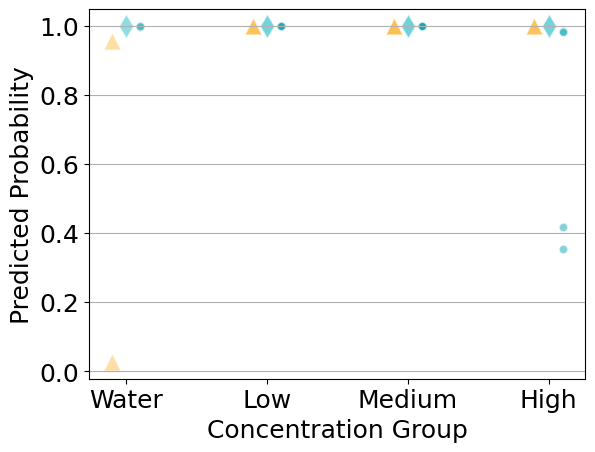

In [32]:
plt.rcParams.update({'font.size': 18})
color_dict = {'igi': '#0b4479', #'#008080',
             'fusion': '#ffbe4f',
             'qpcr':'#6bd2db',
             'deepnet': '#0ea7b5',
             'humanbased': '#ff1493',
             'achievable': '#4682b4'
             }

chip60_boxplot = (chip60_pred_df[['curve_idx','dilution','sample','groundtruth_label','outputs']]
                  .merge(final_chip60_amp_data[['curve_idx','dilution','simulated_new_igi_call']])
                  .merge(chip60_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .merge(chip60_deep_pred[['curve_idx', 'probability']], on='curve_idx')
                #   .merge(chip60_humanbased_pred[['curve_idx', 'outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                  .melt(id_vars=['curve_idx','dilution','groundtruth_label','sample'], var_name='model',
                        value_name='predicted_score')
                  )
chip60_boxplot['str_dilution'] = chip60_boxplot.dilution.astype('str')
chip60_boxplot['model_name'] = chip60_boxplot.model.replace({'outputs':'SPARK',
                                                        'simulated_new_igi_call':'Best Achievable Threshold Rule',
                                                        'prob':'qpcR',
                                                        'probability':'qPCRdeepNet',
                                                        })
chip60_boxplot['model'] = chip60_boxplot.model.replace({'outputs':'fusion',
                                                        'simulated_new_igi_call':'igi',
                                                        'prob':'qpcr',
                                                        'probability':'deepnet',
                                                        })


chip60_boxplot.loc[chip60_boxplot['sample'] == 'Vim', 'dilution_group'] = chip60_boxplot.loc[chip60_boxplot['sample'] == 'Vim'].dilution.map({0: 'Water', 1.e-9: 'Low',  1.e-8: 'Low', 
                                                                                                                                              1.e-3: 'High', 1.e-4: 'High'})
chip60_boxplot.loc[chip60_boxplot['sample'] != 'Vim', 'dilution_group'] = chip60_boxplot.loc[chip60_boxplot['sample'] != 'Vim'].dilution.map({0: 'Water', 1.e-9: 'Low',  1.e-8: 'Low', 
                                                                                                                                              1.e-3: 'High', 1.e-4: 'High'})
chip60_boxplot['dilution_group'] = chip60_boxplot.dilution_group.fillna('Medium')


# chip60_boxplot = chip60_boxplot[['curve_idx','dilution_group','outputs','prob','probability']].groupby(['well_position','dilution_group']).agg('max').reset_index()
# chip60_boxplot = pd.melt(chip60_boxplot, id_vars=['well_position','dilution_group'], var_name='Model', value_name='Prob')
chip60_boxplot['group_idx'] = chip60_boxplot.dilution_group.map({'Water': 0, 'Low': 1, 'Medium': 2, 'High': 3})
chip60_boxplot['xaxis_position'] = chip60_boxplot['group_idx'] + chip60_boxplot.model.map({'fusion': -0.1, 'qpcr': 0, 'deepnet': 0.1})

sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] == 'Vim'][chip60_boxplot.model == 'fusion'], 
                x = 'xaxis_position', y='predicted_score', color=color_dict['fusion'], legend=False, s=150, 
                marker=marker_dict['fusion'], alpha=0.5, label='SPARK')
sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] == 'Vim'][chip60_boxplot.model == 'qpcr'], 
                x = 'xaxis_position', y='predicted_score', color=color_dict['qpcr'], legend=False, s=150, 
                marker=marker_dict['qpcr'],
                alpha = 0.5, label='qpcR')
sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] == 'Vim'][chip60_boxplot.model == 'deepnet'], 
                x = 'xaxis_position', y='predicted_score', color=color_dict['deepnet'], legend=False, s=150, 
                marker=marker_dict['deepnet'], alpha = 0.5, label='qPCRdeepNet')

# plt.title('chip60_boxplot predicted probabilities across dilution levels')
# plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(ticks=[0, 1, 2, 3], labels=['Water', 'Low', 'Medium', 'High'], rotation=0)
plt.xlabel('Concentration Group')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
# plt.legend(False)


/tmp/ipykernel_3866593/1804338026.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] != 'Vim'][chip60_boxplot.model == 'fusion'],
/tmp/ipykernel_3866593/1804338026.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] != 'Vim'][chip60_boxplot.model == 'qpcr'],
/tmp/ipykernel_3866593/1804338026.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] != 'Vim'][chip60_boxplot.model == 'deepnet'],


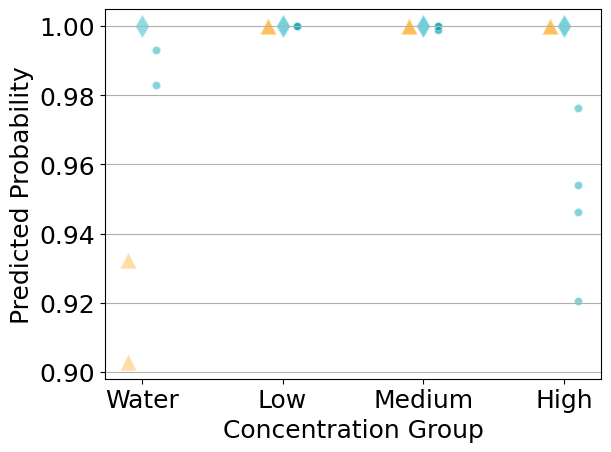

In [33]:

sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] != 'Vim'][chip60_boxplot.model == 'fusion'], 
                x = 'xaxis_position', y='predicted_score', 
                color=color_dict['fusion'], legend=False, s=150, 
                marker=marker_dict['fusion'], alpha=0.5, label='SPARK')
sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] != 'Vim'][chip60_boxplot.model == 'qpcr'], 
                x = 'xaxis_position', y='predicted_score', 
                color=color_dict['qpcr'], legend=False, s=150, 
                marker=marker_dict['qpcr'],
                alpha = 0.5, label='qpcR')
sns.scatterplot(chip60_boxplot[chip60_boxplot['sample'] != 'Vim'][chip60_boxplot.model == 'deepnet'], 
                x = 'xaxis_position', y='predicted_score', 
                color=color_dict['deepnet'], legend=False, s=150, 
                marker=marker_dict['deepnet'],
                alpha = 0.5, label='qPCRdeepNet')

# plt.title('chip60_boxplot predicted probabilities across dilution levels')
# plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(ticks=[0, 1, 2, 3], labels=['Water', 'Low', 'Medium', 'High'], rotation=0)
plt.xlabel('Concentration Group')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')

# plt.legend(loc='lower center', fontsize=20, ncol = 5, bbox_to_anchor=(0.475,-0.5))

In [34]:
chip60_boxplot['pred'] = 0
chip60_boxplot.loc[chip60_boxplot.model == 'fusion', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_model_thres)
chip60_boxplot.loc[chip60_boxplot.model == 'qpcr', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_qpcr_thres)
chip60_boxplot.loc[chip60_boxplot.model == 'deepnet', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_deepnet_thres)
chip60_boxplot.loc[chip60_boxplot.model == 'igi', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_igi_thres)

chip60_boxplot.loc[chip60_boxplot.model == 'fusion', 'accuracy'] = 1*(chip60_boxplot.pred == chip60_boxplot.groundtruth_label)
chip60_boxplot.loc[chip60_boxplot.model == 'qpcr', 'accuracy'] = 1*(chip60_boxplot.pred == chip60_boxplot.groundtruth_label)
chip60_boxplot.loc[chip60_boxplot.model == 'deepnet', 'accuracy'] = 1*(chip60_boxplot.pred == chip60_boxplot.groundtruth_label)
chip60_boxplot.loc[chip60_boxplot.model == 'igi', 'accuracy'] = 1*(chip60_boxplot.pred == chip60_boxplot.groundtruth_label)
                   
# chip60_avg_pred_score = chip60_boxplot.groupby(['dilution','model'])[['groundtruth_label','pred']].apply(lambda x: accuracy_score(x.groundtruth_label, x.pred)).reset_index()
chip60_avg_pred_score = chip60_boxplot.groupby(['dilution','model'])['accuracy'].mean().reset_index(name='avg_accuracy')
# chip60_avg_pred_score.columns = ['dilution','model','accuracy_score']
chip60_avg_pred_score['dilution'] = chip60_avg_pred_score.dilution.astype('str')

### karlen

In [56]:
karlen_pred_df = (karlen_pred
                  .merge(karlen_df[karlen_df.Cycles == 1], on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

karlen_boxplot = (karlen_pred_df[['curve_idx','inv_dilution_fold','dilution_fold','groundtruth_label','outputs']]
                  .merge(karlen_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .merge(karlen_deep_pred[['curve_idx', 'probability']], on='curve_idx')
                  .merge(karlen_humanbased_pred[['curve_idx', 'outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                  .melt(id_vars=['curve_idx','inv_dilution_fold','dilution_fold','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
karlen_boxplot['model'] = karlen_boxplot.model.replace({'outputs':'qPCR-FusionNet',
                                                        'prob':'qpcR',
                                                        'probability':'qPCRdeepNet',
                                                        'human_prob':'Fusion-human'})
# karlen_boxplot['inv_dilution_fold'] = 1/karlen_boxplot.dilution_fold
# karlen_boxplot['inv_dilution_fold'] = karlen_boxplot.inv_dilution_fold.astype('str')

### IGI Simulation
##### karlen

In [41]:
karlen_pred_full = karlen_pred.copy()
karlen_pred_full = (karlen_df
               .merge(karlen_pred_full[['curve_idx','outputs']], on='curve_idx'))

In [42]:
thermo_df = join_df[(join_df.test_kit == 'Thermo') & (join_df.cycle_no == 37)]
thermo_threshold_df = thermo_df.groupby('target').threshold.mean()

thermo_thres_perc_df = pd.DataFrame(thermo_threshold_df)
thermo_thres_perc_df['percentile'] = np.nan
for key in thermo_thres_perc_df.index:
    thermo_thres_perc_df.loc[key,'percentile'] = percentileofscore(thermo_df[thermo_df.target == key].drn, 
                                                         thermo_threshold_df[key], kind='weak')

threshold_40 = thermo_thres_perc_df.percentile.mean()

karlen_threshold = (karlen_pred_full[karlen_pred_full.Cycles == 37]
                    .groupby('data_set')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_40))
                    .reset_index(name='threshold'))

karlen_pred_full = (karlen_pred_full
             .merge(karlen_threshold, on = 'data_set'))

karlen_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_pred_full['pred'] = 1*(karlen_pred_full.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_pred_full.groundtruth_label, karlen_pred_full.pred, labels=np.array([0,1])).ravel()
    
    karlen_model_dict['thres'].append(i)
    karlen_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_model_dict['fnr'].append(fn/(fn+tp))
    karlen_model_dict['fpr'].append(fp/(fp+tn))
    karlen_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_model_dict_df = pd.DataFrame(karlen_model_dict)
    
karlen_thres_df = {'perc':[], 'cycle':[], 'acc':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(31, 41):
        df = karlen_pred_full.copy()
        df['new_threshold'] = karlen_pred_full.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)

        tn, fp, fn, tp = confusion_matrix(df[df.Cycles == 1].groundtruth_label, df[df.Cycles == 1].new_igi_call, labels=np.array([0,1])).ravel()
        
        karlen_thres_df['perc'].append(perc)
        karlen_thres_df['cycle'].append(cycle)
        karlen_thres_df['acc'].append((tp+tn)/(tp+fp+tn+fn))
        karlen_thres_df['fpr'].append(fp/(fp+tn))
        karlen_thres_df['fnr'].append(fn/(fn+tp))
        karlen_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))


/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr

In [43]:

karlen_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_qpcr_pred['pred'] = 1*(karlen_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_qpcr_pred.groundtruth_label, karlen_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_qpcr_dict['thres'].append(i)
    karlen_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_qpcr_dict['fnr'].append(fn/(fn+tp))
    karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
    karlen_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_qpcr_dict_df = pd.DataFrame(karlen_qpcr_dict)

/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(

/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(

In [44]:

karlen_deepnet_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_deep_pred['pred'] = 1*(karlen_deep_pred.probability >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_deep_pred.groundtruth_label, karlen_deep_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_deepnet_dict['thres'].append(i)
    karlen_deepnet_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_deepnet_dict['fnr'].append(fn/(fn+tp))
    karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
    karlen_deepnet_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_deepnet_dict_df = pd.DataFrame(karlen_deepnet_dict)

/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_di

/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_di

In [45]:

karlen_humanbased_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_humanbased_pred['pred'] = 1*(karlen_humanbased_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_humanbased_pred.groundtruth_label, karlen_humanbased_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_humanbased_dict['thres'].append(i)
    karlen_humanbased_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_humanbased_dict['fnr'].append(fn/(fn+tp))
    karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
    karlen_humanbased_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_humanbased_dict_df = pd.DataFrame(karlen_humanbased_dict)

/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
 

/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
 

True positive fraction: 1.0


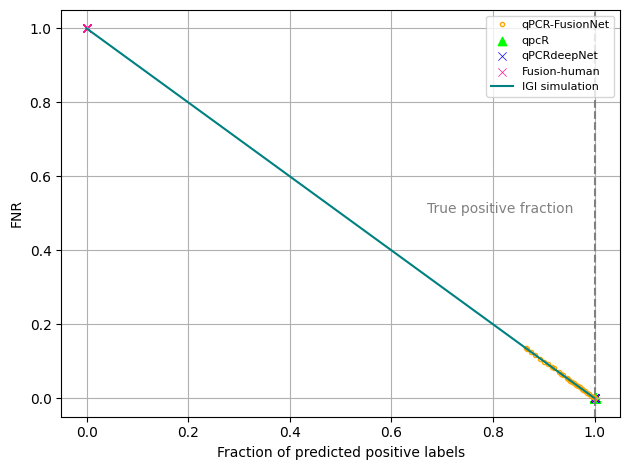

In [46]:
        
karlen_true_pos_frac = sum(karlen_pred_full.groundtruth_label == 1)/karlen_pred_full.shape[0]
print('True positive fraction:', karlen_true_pos_frac)
karlen_thres_df = pd.DataFrame(karlen_thres_df)

plt.plot(karlen_model_dict_df[['pos_frac','fnr']].drop_duplicates().pos_frac, 
         karlen_model_dict_df[['pos_frac','fnr']].drop_duplicates().fnr, 
        #   'o', **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
        marker='o', markersize=3, fillstyle='none', linestyle='none', color=color_map.get('qPCR-FusionNet'),
         linewidth=0.5,
         label='qPCR-FusionNet')
plt.scatter(karlen_qpcr_dict_df.pos_frac, karlen_qpcr_dict_df.fnr, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(karlen_deepnet_dict_df.pos_frac, karlen_deepnet_dict_df.fnr, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidths=0.5, label='qPCRdeepNet')
plt.scatter(karlen_humanbased_dict_df.pos_frac, karlen_humanbased_dict_df.fnr, 
            color=color_map.get('Fusion-human'), marker='x', linewidths=0.5, label='Fusion-human')
plt.plot(karlen_thres_df.pos_pred, 
         karlen_thres_df.fnr, 
         color=color_map.get('IGI'), label='IGI simulation')
plt.axvline(karlen_true_pos_frac, linestyle='--', color='gray')
plt.text(x=karlen_true_pos_frac - 0.33, y = 0.5, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
# plt.title('FNR of different methods when varying thresholds on karlen set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_qpcr_karlen.png')

#### Chip60

In [35]:
chip60_pred_full = chip60_pred.copy()
chip60_pred_full = (chip60_pred_full
                    .merge(chip60_df, on='curve_idx'))

In [36]:
chip60_pred_full.loc[(chip60_pred_full['sample'] == 'Vim') & (chip60_pred_full['Index'] == 1), ['curve_idx', 'outputs','dilution','groundtruth_label']].sort_values('curve_idx')

,curve_idx,outputs,dilution,groundtruth_label
0,Vim.0.1,0.955537,0.000000e+00,0
1170,Vim.0.2,0.026782,0.000000e+00,0
540,Vim.1.1,1.000000,1.000000e-03,1
180,Vim.1.2,1.000000,1.000000e-03,1
900,Vim.2.1,1.000000,1.000000e-04,1
1305,Vim.2.2,1.000000,1.000000e-04,1
225,Vim.3.1,1.000000,1.000000e-05,1
495,Vim.3.2,1.000000,1.000000e-05,1
270,Vim.4.1,1.000000,1.000000e-06,1
630,Vim.4.2,1.000000,1.000000e-06,1


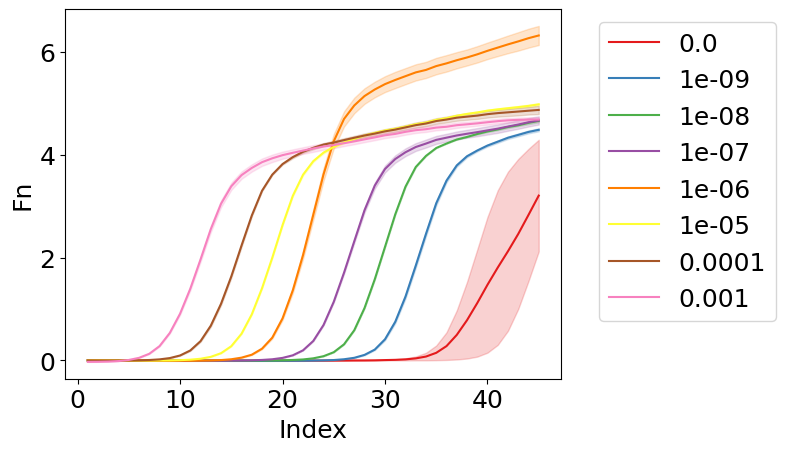

In [37]:
sns.lineplot(chip60_pred_full[chip60_pred_full['sample'] == 'Vim'], x='Index', y='Fn', hue='dilution', palette='Set1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [38]:
luner_df = join_df[(join_df.test_kit == 'LuNER') & (join_df.cycle_no == 40)]
luner_threshold_df = luner_df.groupby('target').threshold.mean()

luner_thres_perc_df = pd.DataFrame(luner_threshold_df)
luner_thres_perc_df['percentile'] = np.nan
for key in luner_thres_perc_df.index:
    luner_thres_perc_df.loc[key,'percentile'] = percentileofscore(luner_df[luner_df.target == key].drn, 
                                                         luner_threshold_df[key], kind='weak')

threshold_45 = luner_thres_perc_df.percentile.mean()

chip60_threshold = (chip60_pred_full[chip60_pred_full['Index'] == 40]
                    .groupby('sample')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_45))
                    .reset_index(name='threshold'))

chip60_pred_full_df = (chip60_pred_full
             .merge(chip60_threshold, on = 'sample'))

chip60_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_pred_full_df['pred'] = 1*(chip60_pred_full_df.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_pred_full_df.groundtruth_label, chip60_pred_full_df.pred, labels=np.array([0,1])).ravel()
    
    chip60_model_dict['thres'].append(i)
    chip60_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_model_dict['fnr'].append(fn/(fn+tp))
    chip60_model_dict['fpr'].append(fp/(fp+tn))
    chip60_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_model_dict_df = pd.DataFrame(chip60_model_dict)
    

chip60_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_qpcr_pred['pred'] = 1*(chip60_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_qpcr_pred.groundtruth_label, chip60_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_qpcr_dict['thres'].append(i)
    chip60_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_qpcr_dict['fnr'].append(fn/(fn+tp))
    chip60_qpcr_dict['fpr'].append(fp/(fp+tn))
    chip60_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_qpcr_dict_df = pd.DataFrame(chip60_qpcr_dict)
    
chip60_deepnet_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_deep_pred['pred'] = 1*(chip60_deep_pred.probability >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_deep_pred.groundtruth_label, chip60_deep_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_deepnet_dict['thres'].append(i)
    chip60_deepnet_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_deepnet_dict['fnr'].append(fn/(fn+tp))
    chip60_deepnet_dict['fpr'].append(fp/(fp+tn))
    chip60_deepnet_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_deepnet_dict_df = pd.DataFrame(chip60_deepnet_dict)
    
chip60_humanbased_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_humanbased_pred['pred'] = 1*(chip60_humanbased_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_humanbased_pred.groundtruth_label, chip60_humanbased_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_humanbased_dict['thres'].append(i)
    chip60_humanbased_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_humanbased_dict['fnr'].append(fn/(fn+tp))
    chip60_humanbased_dict['fpr'].append(fp/(fp+tn))
    chip60_humanbased_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_humanbased_dict_df = pd.DataFrame(chip60_humanbased_dict)

chip60_thres_df = {'perc':[], 'cycle':[], 'acc':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(35, 45):
        df = chip60_pred_full_df.copy()
        df['new_threshold'] = chip60_pred_full_df.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)
        df_1 = df[df['Index'] == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        chip60_thres_df['perc'].append(perc) #[perc]*len(tn)
        chip60_thres_df['cycle'].append(cycle) #[cycle]*len(tn)
        chip60_thres_df['fpr'].append(fp/(fp+tn))
        chip60_thres_df['acc'].append((tp+tn)/(tp+fp+tn+fn))
        chip60_thres_df['fnr'].append(fn/(fn+tp))
        chip60_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
chip60_true_pos_frac = sum(chip60_pred_full_df.groundtruth_label == 1)/chip60_pred_full_df.shape[0]
print('True positive fraction:', chip60_true_pos_frac)

chip60_thres_df = pd.DataFrame(chip60_thres_df)


True positive fraction: 0.875


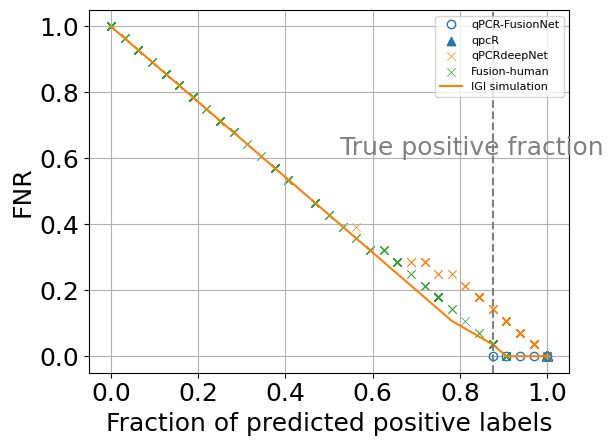

In [39]:

plt.plot(chip60_model_dict_df[['pos_frac','fnr']].drop_duplicates().pos_frac, 
         chip60_model_dict_df[['pos_frac','fnr']].drop_duplicates().fnr, 
         marker='o', fillstyle='none', linestyle='none', 
         color=color_map.get('qPCR-FusionNet'), linewidth=0.0005,
        #  **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
         label='qPCR-FusionNet')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fnr, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(chip60_deepnet_dict_df.pos_frac, chip60_deepnet_dict_df.fnr, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidth=0.5,
            # 'x', **{'mfc': 'none', 'mec':color_map.get('qPCRdeepNet'),'mew':0.8},
            label='qPCRdeepNet')
plt.scatter(chip60_humanbased_dict_df.pos_frac, chip60_humanbased_dict_df.fnr, 
            color=color_map.get('Fusion-human'), marker='x', linewidth=0.5,
            label='Fusion-human')

plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fnr, 
         color=color_map.get('IGI'), label='IGI simulation')

# plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')



plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
# plt.title('FNR of different methods when varying thresholds on chip60 set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_qpcr_chip60.png')

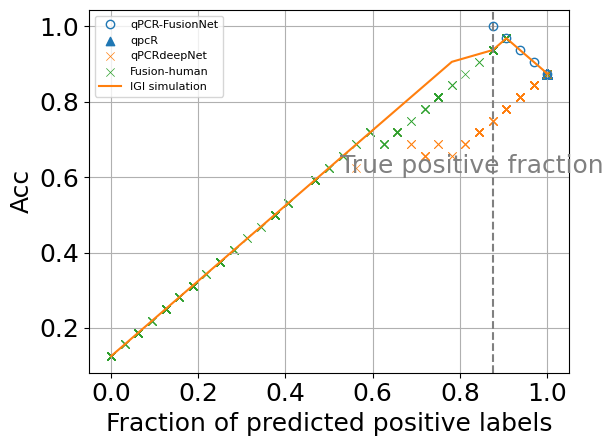

In [40]:
# plt.plot(chip60_thres_df.pos_pred, 
#          chip60_thres_df.acc, 
#          '.', **{'mfc': 'none', 'mec':'green','mew':0.8}, label='IGI simulation')

# # plt.plot(igi_pos_frac, igi_acc, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.acc, color='blue', label='Model')
# plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.acc, color='orange', marker='x', label='qpcR')



plt.plot(chip60_model_dict_df[['pos_frac','acc']].drop_duplicates().pos_frac, 
         chip60_model_dict_df[['pos_frac','acc']].drop_duplicates().acc, 
         marker='o', fillstyle='none', linestyle='none', 
         color=color_map.get('qPCR-FusionNet'), linewidth=0.0005,
        #  **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
         label='qPCR-FusionNet')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.acc, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(chip60_deepnet_dict_df.pos_frac, chip60_deepnet_dict_df.acc, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidth=0.5,
            # 'x', **{'mfc': 'none', 'mec':color_map.get('qPCRdeepNet'),'mew':0.8},
            label='qPCRdeepNet')
plt.scatter(chip60_humanbased_dict_df.pos_frac, chip60_humanbased_dict_df.acc, 
            color=color_map.get('Fusion-human'), marker='x', linewidth=0.5,
            label='Fusion-human')

plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.acc, 
         color=color_map.get('IGI'), label='IGI simulation')


plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('Acc')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
# plt.title('FPR of different methods when varying thresholds on chip60 set')
plt.tight_layout()
# plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/acc_qpcr_chip60.png')

In [45]:
chip60_qpcr_dict_df.sort_values('acc', ascending=False).head(1)

,thres,acc,fnr,fpr,pos_frac
0,0.0,0.875,0.0,1.0,1.0


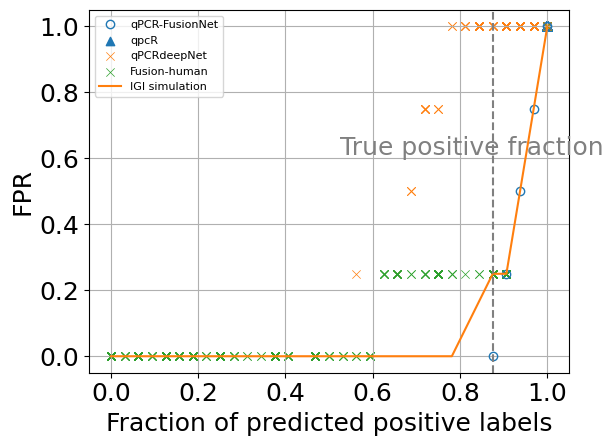

In [46]:
# plt.plot(chip60_thres_df.pos_pred, 
#          chip60_thres_df.fpr, 
#          '.', **{'mfc': 'none', 'mec':'green','mew':0.8}, label='IGI simulation')

# # plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.fpr, color='blue', label='Model')
# plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fpr, color='orange', marker='x', label='qpcR')



plt.plot(chip60_model_dict_df[['pos_frac','fpr']].drop_duplicates().pos_frac, 
         chip60_model_dict_df[['pos_frac','fpr']].drop_duplicates().fpr, 
         marker='o', fillstyle='none', linestyle='none', 
         color=color_map.get('qPCR-FusionNet'), linewidth=0.0005,
        #  **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
         label='qPCR-FusionNet')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fpr, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(chip60_deepnet_dict_df.pos_frac, chip60_deepnet_dict_df.fpr, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidth=0.5,
            # 'x', **{'mfc': 'none', 'mec':color_map.get('qPCRdeepNet'),'mew':0.8},
            label='qPCRdeepNet')
plt.scatter(chip60_humanbased_dict_df.pos_frac, chip60_humanbased_dict_df.fpr, 
            color=color_map.get('Fusion-human'), marker='x', linewidth=0.5,
            label='Fusion-human')

plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fpr, 
         color=color_map.get('IGI'), label='IGI simulation')


plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
# plt.title('FPR of different methods when varying thresholds on chip60 set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fpr_qpcr_chip60.png')

# Bootstrap

In [41]:
test_color_map = {'Best achievable threshold rule': 'mediumorchid',
 'SPARK': '#ffa500',
 'qpcR': '#00ff00',
 'qPCRdeepNet': '#0000ff',
 'humanbased': '#ff1493'}
test = boxplot_df[['well_position','dilution_level','target','outputs','prob','probability','simulated_new_igi_call']].melt(id_vars=['well_position','dilution_level','target'], var_name='model',
                        value_name='predicted_score')
test = test[test.target.isin(['N gene','E gene'])]
test['groundtruth_label'] = 1*(test.dilution_level != 0)
test['model'] = test.model.replace({'outputs':'SPARK',
                                    'prob':'qpcR',
                                    'probability':'qPCRdeepNet',
                                    'simulated_new_igi_call':'Best achievable threshold rule'})
test['group'] = test.dilution_level.map({0: 'Water', 1: 'low', 100000:'high'})
test['group'] = test.group.fillna('normal')

In [42]:
wide_test = test.pivot(index=['well_position','dilution_level','model'], columns='target', values='predicted_score').reset_index()
wide_test['combined_prob'] = wide_test[['N gene','E gene']].max(axis=1)

In [43]:
thres_dict = {'qpcR': best_qpcr_test_acc_thres,
             'SPARK': best_test_acc_thres,
             'qPCRdeepNet': best_deepnet_test_acc_thres,
             'Best achievable threshold rule': 1}

chip_thres_dict = {'qpcR': best_qpcr_thres,
             'SPARK': best_model_thres,
             'qPCRdeepNet': best_deepnet_thres,
             'Best achievable threshold rule': best_igi_thres}

In [44]:


def bootstrap_auc(df, n_bootstrap=1000):
    auc_df = pd.DataFrame()
    for _ in range(n_bootstrap):
        sampled_wells = df[['dilution_level','well_position']].drop_duplicates().groupby(['dilution_level'], group_keys=False).apply(lambda x: x.well_position.sample(n=x.shape[0], replace=True)).reset_index()
        resample_df = df.merge(sampled_wells, on=['well_position'], how='right')
        final_df = resample_df.groupby(['well_position','model','groundtruth_label']).predicted_score.mean().reset_index(name='major_prob')
        auc_df = pd.concat([auc_df, final_df.groupby(['model']).apply(lambda x: roc_auc_score(x.groundtruth_label, x.major_prob, labels=[0,1])).reset_index(name='auc')])
        # bootstrap_df = pd.concat([bootstrap_df, final_df])
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean[['lower','upper']] = bootstrap_mean[['major_prob']].apply(lambda x: x.quantile([0.025, 0.975]))
    # lower = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.025).reset_index()
    # upper = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.975).reset_index()
    
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean['lower'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.025))).reset_index(drop=True))
    # bootstrap_mean['upper'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.975))).reset_index(drop=True))

    return auc_df






def bootstrap_accuracy(df, thres_dict, n_bootstrap=1000, groups=['model']):
    np.random.seed(42)
    auc_df = pd.DataFrame()
    for _ in range(n_bootstrap):
        sampled_wells = df[['dilution_level','well_position']].drop_duplicates().groupby(['dilution_level'], group_keys=False).apply(lambda x: x.well_position.sample(n=x.shape[0], replace=True)).reset_index()
        resample_df = df.merge(sampled_wells, on=['well_position'], how='right')
        resample_df['threshold'] = resample_df.model.map(thres_dict)
        resample_df['pred'] = 1*(resample_df.predicted_score >= resample_df.threshold)
        final_df = resample_df.groupby(groups+['well_position','groundtruth_label']).pred.mean().reset_index(name='major_prob')
        final_df['major_prob'] = final_df.major_prob.apply(lambda x: 1 if x >= 0.5 else 0)
        auc_df = pd.concat([auc_df, final_df.groupby(groups).apply(lambda x: accuracy_score(x.groundtruth_label, x.major_prob)).reset_index(name='accuracy')])
        # bootstrap_df = pd.concat([bootstrap_df, final_df])
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean[['lower','upper']] = bootstrap_mean[['major_prob']].apply(lambda x: x.quantile([0.025, 0.975]))
    # lower = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.025).reset_index()
    # upper = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.975).reset_index()
    
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean['lower'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.025))).reset_index(drop=True))
    # bootstrap_mean['upper'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.975))).reset_index(drop=True))

    return auc_df


def bootstrap_accuracy(df, thres_dict, n_bootstrap=1000, groups=['model']):
    np.random.seed(42)
    acc_df = pd.DataFrame()
    for _ in range(n_bootstrap):
        sampled_wells = df[['dilution_level','well_position']].drop_duplicates().groupby(['dilution_level'], group_keys=False).apply(lambda x: x.well_position.sample(n=x.shape[0], replace=True)).reset_index()
        resample_df = df.merge(sampled_wells, on=['well_position'], how='right')
        resample_df['threshold'] = resample_df.model.map(thres_dict)
        resample_df['pred'] = 1*(resample_df.predicted_score >= resample_df.threshold)
        final_df = resample_df.groupby(groups+['well_position','groundtruth_label']).pred.mean().reset_index(name='major_prob')
        final_df['major_prob'] = final_df.major_prob.apply(lambda x: 1 if x >= 0.5 else 0)
        acc_df = pd.concat([acc_df, final_df.groupby(groups).apply(lambda x: accuracy_score(x.groundtruth_label, x.major_prob)).reset_index(name='accuracy')])
        # bootstrap_df = pd.concat([bootstrap_df, final_df])
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean[['lower','upper']] = bootstrap_mean[['major_prob']].apply(lambda x: x.quantile([0.025, 0.975]))
    # lower = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.025).reset_index()
    # upper = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.975).reset_index()
    
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean['lower'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.025))).reset_index(drop=True))
    # bootstrap_mean['upper'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.975))).reset_index(drop=True))

    return acc_df

In [45]:
# bootstrap_auc_outputs = bootstrap_auc(test)
bootstrap_accuracy_outputs = bootstrap_accuracy(test, thres_dict=thres_dict, groups=['model','group'])

In [46]:
bootstrap_accuracy_outputs.groupby(['model', 'group']).agg({'accuracy': ['mean', lambda x: np.quantile(x, 0.975), lambda x: np.quantile(x, 0.025)]}).reset_index().rename(columns={'mean':'auc','<lambda_0>':'upper','<lambda_1>':'lower'})

model   group  accuracy                
                                                 auc upper     lower
0   Best achievable threshold rule   Water  1.000000   1.0  1.000000
1   Best achievable threshold rule    high  1.000000   1.0  1.000000
2   Best achievable threshold rule     low  0.956038   1.0  0.923077
3   Best achievable threshold rule  normal  1.000000   1.0  1.000000
4                            SPARK   Water  1.000000   1.0  1.000000
5                            SPARK    high  1.000000   1.0  1.000000
6                            SPARK     low  1.000000   1.0  1.000000
7                            SPARK  normal  1.000000   1.0  1.000000
8                      qPCRdeepNet   Water  0.875883   1.0  0.750000
9                      qPCRdeepNet    high  1.000000   1.0  1.000000
10                     qPCRdeepNet     low  0.956038   1.0  0.923077
11                     qPCRdeepNet  normal  1.000000   1.0  1.000000
12                            qpcR   Water  1.000000   1.0  1.000000
13                            qpcR    high  1.000000   1.0  1.000000
14                            qpcR     low  0.956038   1.0  0.923077
15                            qpcR  normal  1.000000   1.0  1.000000

In [47]:
chip60_bootstrap_df = chip60_boxplot.rename(columns={'dilution': 'dilution_level', 'curve_idx': 'well_position'}).copy()
chip60_bootstrap_df['model'] = chip60_bootstrap_df.model.replace({'fusion':'SPARK', 'igi':'Best achievable threshold rule', 'qpcr':'qpcR', 'deepnet':'qPCRdeepNet'})
chip60_bootstrap_df['group'] = 'high'
chip60_bootstrap_df.loc[chip60_bootstrap_df['sample'] == 'Vim', 'group'] = chip60_bootstrap_df.loc[chip60_bootstrap_df['sample'] == 'Vim'].dilution_level.map({0: 'Water', 1.e-3: 'high', 1.e-4: 'high', 1.e-9: 'low', 1.e-8: 'low'})
chip60_bootstrap_df.loc[chip60_bootstrap_df['sample'] != 'Vim', 'group'] = chip60_bootstrap_df.loc[chip60_bootstrap_df['sample'] != 'Vim'].dilution_level.map({0: 'Water', 1.e-3: 'high', 1.e-4: 'high', 1.e-9: 'low', 1.e-8: 'low'})
chip60_bootstrap_df['group'] = chip60_bootstrap_df.group.fillna('normal')
# chip60_bootstrap_auc_outputs = bootstrap_auc(chip60_bootstrap_df)
chip60_bootstrap_accuracy_outputs = bootstrap_accuracy(chip60_bootstrap_df, thres_dict=chip_thres_dict, groups=['model','group','sample'])

In [48]:
chip60_bootstrap_accuracy_outputs[chip60_bootstrap_accuracy_outputs['sample'] == 'MLC2v'].groupby(['model', 'group']).agg({'accuracy': ['mean', 
                                                                                                                                        lambda x: np.quantile(x, 0.975), 
                                                                                                                                        lambda x: np.quantile(x, 0.025),
                                                                                                                                        'count']}).reset_index().rename(columns={'mean':'acc','<lambda_0>':'upper','<lambda_1>':'lower', 'count':'cnt'})

model   group accuracy                  
                                                acc upper lower   cnt
0   Best achievable threshold rule   Water  0.49574   1.0   0.0   939
1   Best achievable threshold rule    high  1.00000   1.0   1.0   996
2   Best achievable threshold rule     low  1.00000   1.0   1.0   994
3   Best achievable threshold rule  normal  1.00000   1.0   1.0  1000
4                            SPARK   Water  1.00000   1.0   1.0   939
5                            SPARK    high  1.00000   1.0   1.0   996
6                            SPARK     low  1.00000   1.0   1.0   994
7                            SPARK  normal  1.00000   1.0   1.0  1000
8                      qPCRdeepNet   Water  1.00000   1.0   1.0   939
9                      qPCRdeepNet    high  0.00000   0.0   0.0   996
10                     qPCRdeepNet     low  1.00000   1.0   1.0   994
11                     qPCRdeepNet  normal  1.00000   1.0   1.0  1000
12                            qpcR   Water  0.00000   0.0   0.0   939
13                            qpcR    high  1.00000   1.0   1.0   996
14                            qpcR     low  1.00000   1.0   1.0   994
15                            qpcR  normal  1.00000   1.0   1.0  1000

In [50]:
chip60_bootstrap_accuracy_outputs[chip60_bootstrap_accuracy_outputs['sample'] == 'Vim'].groupby(['model', 'group']).agg({'accuracy': ['mean', 
                                                                                                                                        lambda x: np.quantile(x, 0.975), 
                                                                                                                                        lambda x: np.quantile(x, 0.025),
                                                                                                                                        'count']}).reset_index().rename(columns={'mean':'acc','<lambda_0>':'upper','<lambda_1>':'lower', 'count':'cnt'})

model   group  accuracy                  
                                                 acc upper lower   cnt
0   Best achievable threshold rule   Water  0.498399   1.0   0.0   937
1   Best achievable threshold rule    high  1.000000   1.0   1.0   998
2   Best achievable threshold rule     low  1.000000   1.0   1.0   994
3   Best achievable threshold rule  normal  1.000000   1.0   1.0  1000
4                            SPARK   Water  1.000000   1.0   1.0   937
5                            SPARK    high  1.000000   1.0   1.0   998
6                            SPARK     low  1.000000   1.0   1.0   994
7                            SPARK  normal  1.000000   1.0   1.0  1000
8                      qPCRdeepNet   Water  0.498399   1.0   0.0   937
9                      qPCRdeepNet    high  0.000000   0.0   0.0   998
10                     qPCRdeepNet     low  1.000000   1.0   1.0   994
11                     qPCRdeepNet  normal  1.000000   1.0   1.0  1000
12                            qpcR   Water  0.000000   0.0   0.0   937
13                            qpcR    high  1.000000   1.0   1.0   998
14                            qpcR     low  1.000000   1.0   1.0   994
15                            qpcR  normal  1.000000   1.0   1.0  1000

In [68]:
chip60_bootstrap_df[chip60_bootstrap_df['sample'] == 'Vim'][chip60_bootstrap_df.model == 'SPARK'].sort_values('dilution_group')

/tmp/ipykernel_1961022/2176526295.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  chip60_bootstrap_df[chip60_bootstrap_df['sample'] == 'Vim'][chip60_bootstrap_df.model == 'SPARK'].sort_values('dilution_group')


,well_position,dilution_level,groundtruth_label,sample,model,predicted_score,str_dilution,model_name,dilution_group,group_idx,xaxis_position,group
4,Vim.1.2,1.000000e-03,1,Vim,SPARK,1.000000,0.001,SPARK,High,3,2.9,high
12,Vim.1.1,1.000000e-03,1,Vim,SPARK,1.000000,0.001,SPARK,High,3,2.9,high
20,Vim.2.1,1.000000e-04,1,Vim,SPARK,1.000000,0.0001,SPARK,High,3,2.9,high
29,Vim.2.2,1.000000e-04,1,Vim,SPARK,1.000000,0.0001,SPARK,High,3,2.9,high
3,Vim.7.1,1.000000e-09,1,Vim,SPARK,1.000000,1e-09,SPARK,Low,1,0.9,low
30,Vim.7.2,1.000000e-09,1,Vim,SPARK,1.000000,1e-09,SPARK,Low,1,0.9,low
2,Vim.6.1,1.000000e-08,1,Vim,SPARK,1.000000,1e-08,SPARK,Medium,2,1.9,normal
5,Vim.3.1,1.000000e-05,1,Vim,SPARK,1.000000,1e-05,SPARK,Medium,2,1.9,normal
6,Vim.4.1,1.000000e-06,1,Vim,SPARK,1.000000,1e-06,SPARK,Medium,2,1.9,normal
9,Vim.6.2,1.000000e-08,1,Vim,SPARK,1.000000,1e-08,SPARK,Medium,2,1.9,normal


In [49]:
chip60_boxplot[chip60_boxplot.model == 'fusion'].groupby(['sample','dilution_group']).curve_idx.nunique()

sample  dilution_group
MLC2v   High              4
        Low               4
        Medium            6
        Water             2
Vim     High              4
        Low               4
        Medium            6
        Water             2
Name: curve_idx, dtype: int64

In [57]:
test.groupby('group').well_position.nunique()

group
Water      8
high      15
low       24
normal    57
Name: well_position, dtype: int64

In [74]:
chip60_accuracy_df = chip60_bootstrap_accuracy_outputs.groupby(['model','sample','group']).agg({'accuracy': ['mean', lambda x: np.quantile(x, 0.975), lambda x: np.quantile(x, 0.025)]}).reset_index().rename(columns={'mean':'accuracy','<lambda_0>':'upper','<lambda_1>':'lower'})
chip60_accuracy_df['lower'] = np.abs(chip60_accuracy_df['accuracy']['accuracy'] - chip60_accuracy_df['accuracy']['lower'])
chip60_accuracy_df['upper'] = np.abs(chip60_accuracy_df['accuracy']['accuracy'] - chip60_accuracy_df['accuracy']['upper'])

In [75]:
chip60_accuracy_df[chip60_accuracy_df['sample'] == 'MLC2v'].sort_values(['group','model'])

model sample   group accuracy              \
                                                  accuracy upper lower   
0   Best achievable threshold rule  MLC2v   Water  0.49574   1.0   0.0   
8                            SPARK  MLC2v   Water  1.00000   1.0   1.0   
16                     qPCRdeepNet  MLC2v   Water  1.00000   1.0   1.0   
24                            qpcR  MLC2v   Water  0.00000   0.0   0.0   
1   Best achievable threshold rule  MLC2v    high  1.00000   1.0   1.0   
9                            SPARK  MLC2v    high  1.00000   1.0   1.0   
17                     qPCRdeepNet  MLC2v    high  0.00000   0.0   0.0   
25                            qpcR  MLC2v    high  1.00000   1.0   1.0   
2   Best achievable threshold rule  MLC2v     low  1.00000   1.0   1.0   
10                           SPARK  MLC2v     low  1.00000   1.0   1.0   
18                     qPCRdeepNet  MLC2v     low  1.00000   1.0   1.0   
26                            qpcR  MLC2v     low  1.00000   1.0   1.0   
3   Best achievable threshold rule  MLC2v  normal  1.00000   1.0   1.0   
11                           SPARK  MLC2v  normal  1.00000   1.0   1.0   
19                     qPCRdeepNet  MLC2v  normal  1.00000   1.0   1.0   
27                            qpcR  MLC2v  normal  1.00000   1.0   1.0   

      lower    upper  
                      
0   0.49574  0.50426  
8   0.00000  0.00000  
16  0.00000  0.00000  
24  0.00000  0.00000  
1   0.00000  0.00000  
9   0.00000  0.00000  
17  0.00000  0.00000  
25  0.00000  0.00000  
2   0.00000  0.00000  
10  0.00000  0.00000  
18  0.00000  0.00000  
26  0.00000  0.00000  
3   0.00000  0.00000  
11  0.00000  0.00000  
19  0.00000  0.00000  
27  0.00000  0.00000

In [62]:
chip60_bootstrap_df

,well_position,dilution_level,groundtruth_label,sample,model,predicted_score,str_dilution,model_name,dilution_group,group_idx,xaxis_position,pred,accuracy,group
0,Vim.0.1,0.000000e+00,0,Vim,SPARK,0.955537,0.0,SPARK,Water,0,-0.1,0,1.0,Water
1,MLC2v.4.1,1.000000e-06,1,MLC2v,SPARK,1.000000,1e-06,SPARK,Medium,2,1.9,1,1.0,normal
2,Vim.6.1,1.000000e-08,1,Vim,SPARK,1.000000,1e-08,SPARK,Low,1,0.9,1,1.0,low
3,Vim.7.1,1.000000e-09,1,Vim,SPARK,1.000000,1e-09,SPARK,Low,1,0.9,1,1.0,low
4,Vim.1.2,1.000000e-03,1,Vim,SPARK,1.000000,0.001,SPARK,High,3,2.9,1,1.0,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,MLC2v.5.2,1.000000e-07,1,MLC2v,qPCRdeepNet,0.999921,1e-07,qPCRdeepNet,Medium,2,2.1,1,1.0,normal
124,MLC2v.4.2,1.000000e-06,1,MLC2v,qPCRdeepNet,0.999858,1e-06,qPCRdeepNet,Medium,2,2.1,1,1.0,normal
125,Vim.2.2,1.000000e-04,1,Vim,qPCRdeepNet,0.981693,0.0001,qPCRdeepNet,Medium,2,2.1,0,0.0,normal
126,Vim.7.2,1.000000e-09,1,Vim,qPCRdeepNet,0.999954,1e-09,qPCRdeepNet,Low,1,1.1,1,1.0,low


In [76]:
chip60_bootstrap_df['threshold'] = chip60_bootstrap_df.model.map(chip_thres_dict)
chip60_bootstrap_df['pred'] = 1*(chip60_bootstrap_df.predicted_score >= chip60_bootstrap_df.threshold)
final_df = chip60_bootstrap_df.groupby(['model','sample','group','well_position','groundtruth_label']).pred.mean().reset_index(name='major_prob')
final_df['major_prob'] = final_df.major_prob.apply(lambda x: 1 if x >= 0.5 else 0)
final_df.groupby(['model','sample','group']).apply(lambda x: accuracy_score(x.groundtruth_label, x.major_prob)).reset_index(name='accuracy')

,model,sample,group,accuracy
0,Best achievable threshold rule,MLC2v,Water,0.5
1,Best achievable threshold rule,MLC2v,high,1.0
2,Best achievable threshold rule,MLC2v,low,1.0
3,Best achievable threshold rule,MLC2v,normal,1.0
4,Best achievable threshold rule,Vim,Water,0.5
5,Best achievable threshold rule,Vim,high,1.0
6,Best achievable threshold rule,Vim,low,1.0
7,Best achievable threshold rule,Vim,normal,1.0
8,SPARK,MLC2v,Water,1.0
9,SPARK,MLC2v,high,1.0


In [77]:
chip60_accuracy_df[chip60_accuracy_df['sample'] == 'MLC2v']

model sample   group accuracy              \
                                                  accuracy upper lower   
0   Best achievable threshold rule  MLC2v   Water  0.49574   1.0   0.0   
1   Best achievable threshold rule  MLC2v    high  1.00000   1.0   1.0   
2   Best achievable threshold rule  MLC2v     low  1.00000   1.0   1.0   
3   Best achievable threshold rule  MLC2v  normal  1.00000   1.0   1.0   
8                            SPARK  MLC2v   Water  1.00000   1.0   1.0   
9                            SPARK  MLC2v    high  1.00000   1.0   1.0   
10                           SPARK  MLC2v     low  1.00000   1.0   1.0   
11                           SPARK  MLC2v  normal  1.00000   1.0   1.0   
16                     qPCRdeepNet  MLC2v   Water  1.00000   1.0   1.0   
17                     qPCRdeepNet  MLC2v    high  0.00000   0.0   0.0   
18                     qPCRdeepNet  MLC2v     low  1.00000   1.0   1.0   
19                     qPCRdeepNet  MLC2v  normal  1.00000   1.0   1.0   
24                            qpcR  MLC2v   Water  0.00000   0.0   0.0   
25                            qpcR  MLC2v    high  1.00000   1.0   1.0   
26                            qpcR  MLC2v     low  1.00000   1.0   1.0   
27                            qpcR  MLC2v  normal  1.00000   1.0   1.0   

      lower    upper  
                      
0   0.49574  0.50426  
1   0.00000  0.00000  
2   0.00000  0.00000  
3   0.00000  0.00000  
8   0.00000  0.00000  
9   0.00000  0.00000  
10  0.00000  0.00000  
11  0.00000  0.00000  
16  0.00000  0.00000  
17  0.00000  0.00000  
18  0.00000  0.00000  
19  0.00000  0.00000  
24  0.00000  0.00000  
25  0.00000  0.00000  
26  0.00000  0.00000  
27  0.00000  0.00000

In [ ]:
sars_accuracy_df = bootstrap_accuracy_outputs.groupby(['model','group']).agg({'accuracy': ['mean', lambda x: np.quantile(x, 0.975), lambda x: np.quantile(x, 0.025)]}).reset_index().rename(columns={'mean':'auc','<lambda_0>':'upper','<lambda_1>':'lower'})
sars_accuracy_df['lower'] = np.abs(sars_accuracy_df['accuracy']['auc'] - sars_accuracy_df['accuracy']['lower'])
sars_accuracy_df['upper'] = np.abs(sars_accuracy_df['accuracy']['auc'] - sars_accuracy_df['accuracy']['upper'])

In [ ]:
# fig, axes = plt.subplots(1,2, figsize=(12,4))

# xlabels = [str(x) for x in sorted(sars_accuracy_df.group.unique())]
xlabels = ['Water', 'low','normal','high']
sars_accuracy_df['x_numeric'] = sars_accuracy_df.group.apply(lambda x: xlabels.index(str(x)))
plt.errorbar(sars_accuracy_df[sars_accuracy_df.model == 'qpcR'].x_numeric - 0.1, sars_accuracy_df[sars_accuracy_df.model == 'qpcR']['accuracy']['auc'], 
            yerr=[sars_accuracy_df[sars_accuracy_df.model == 'qpcR']['lower'], sars_accuracy_df[sars_accuracy_df.model == 'qpcR']['upper']], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR', zorder=1)
plt.errorbar(sars_accuracy_df[sars_accuracy_df.model == 'SPARK'].x_numeric - 0.3, sars_accuracy_df[sars_accuracy_df.model == 'SPARK']['accuracy']['auc'], 
            yerr=[sars_accuracy_df[sars_accuracy_df.model == 'SPARK']['lower'], sars_accuracy_df[sars_accuracy_df.model == 'SPARK']['upper']], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK', zorder=4)
plt.errorbar(sars_accuracy_df[sars_accuracy_df.model == 'qPCRdeepNet'].x_numeric + 0.1, sars_accuracy_df[sars_accuracy_df.model == 'qPCRdeepNet']['accuracy']['auc'], 
            yerr=[sars_accuracy_df[sars_accuracy_df.model == 'qPCRdeepNet']['lower'], sars_accuracy_df[sars_accuracy_df.model == 'qPCRdeepNet']['upper']], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
plt.errorbar(sars_accuracy_df[sars_accuracy_df.model == 'Best achievable threshold rule'].x_numeric + 0.3, sars_accuracy_df[sars_accuracy_df.model == 'Best achievable threshold rule']['accuracy']['auc'], 
            yerr=[sars_accuracy_df[sars_accuracy_df.model == 'Best achievable threshold rule']['lower'], sars_accuracy_df[sars_accuracy_df.model == 'Best achievable threshold rule']['upper']], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
plt.xticks(np.arange(0,4,1), labels=['Water'] + xlabels[1:])
plt.legend()
plt.xlabel('Viral Load Level')
plt.ylabel('Sample Prediction Accuracy')
plt.title('SARS-CoV-2')

NameError: name 'sars_accuracy_df' is not defined

/tmp/ipykernel_661079/3438760611.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vim_df['x_numeric'] = vim_df.group.apply(lambda x: xlabels.index(str(x)))
/tmp/ipykernel_661079/3438760611.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mlc_df['x_numeric'] = mlc_df.group.apply(lambda x: xlabels.index(str(x)))


Text(0.5, 1.0, 'MLC-2v')

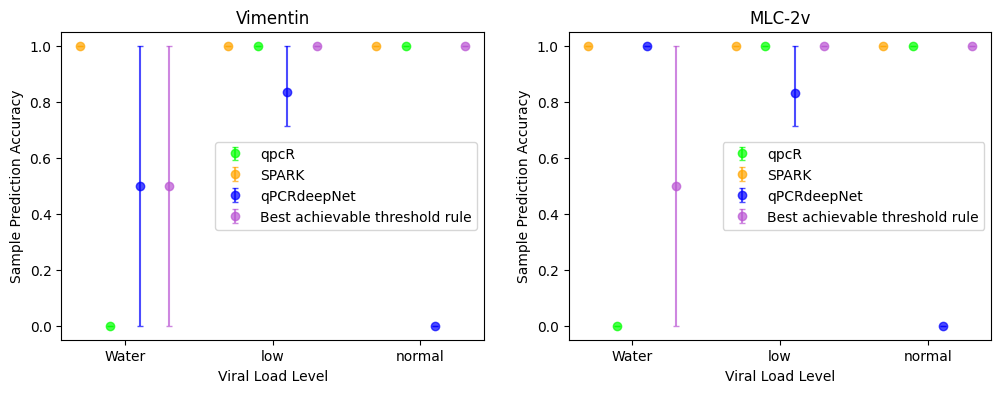

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
vim_df = chip60_accuracy_df[chip60_accuracy_df['sample'] == 'Vim']
xlabels = [str(x) for x in sorted(vim_df.group.unique())]
vim_df['x_numeric'] = vim_df.group.apply(lambda x: xlabels.index(str(x)))
axes[0].errorbar(vim_df[vim_df.model == 'qpcR'].x_numeric - 0.1, vim_df[vim_df.model == 'qpcR']['accuracy']['auc'], 
            yerr=[vim_df[vim_df.model == 'qpcR']['lower'], vim_df[vim_df.model == 'qpcR']['upper']], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR', zorder=1)
axes[0].errorbar(vim_df[vim_df.model == 'SPARK'].x_numeric - 0.3, vim_df[vim_df.model == 'SPARK']['accuracy']['auc'], 
            yerr=[vim_df[vim_df.model == 'SPARK']['lower'], vim_df[vim_df.model == 'SPARK']['upper']], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK', zorder=4)
axes[0].errorbar(vim_df[vim_df.model == 'qPCRdeepNet'].x_numeric + 0.1, vim_df[vim_df.model == 'qPCRdeepNet']['accuracy']['auc'], 
            yerr=[vim_df[vim_df.model == 'qPCRdeepNet']['lower'], vim_df[vim_df.model == 'qPCRdeepNet']['upper']], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
axes[0].errorbar(vim_df[vim_df.model == 'Best achievable threshold rule'].x_numeric + 0.3, vim_df[vim_df.model == 'Best achievable threshold rule']['accuracy']['auc'], 
            yerr=[vim_df[vim_df.model == 'Best achievable threshold rule']['lower'], vim_df[vim_df.model == 'Best achievable threshold rule']['upper']], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
axes[0].set_xticks(np.arange(0,3,1), labels=['Water'] + xlabels[1:])
axes[0].legend()
axes[0].set_xlabel('Viral Load Level')
axes[0].set_ylabel('Sample Prediction Accuracy')
axes[0].set_title('Vimentin')


mlc_df = chip60_accuracy_df[chip60_accuracy_df['sample'] != 'Vim']
xlabels = [str(x) for x in sorted(mlc_df.group.unique())]
mlc_df['x_numeric'] = mlc_df.group.apply(lambda x: xlabels.index(str(x)))
axes[1].errorbar(mlc_df[mlc_df.model == 'qpcR'].x_numeric - 0.1, mlc_df[mlc_df.model == 'qpcR']['accuracy']['auc'], 
            yerr=[mlc_df[mlc_df.model == 'qpcR']['lower'], mlc_df[mlc_df.model == 'qpcR']['upper']], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR', zorder=1)
axes[1].errorbar(mlc_df[mlc_df.model == 'SPARK'].x_numeric - 0.3, mlc_df[mlc_df.model == 'SPARK']['accuracy']['auc'], 
            yerr=[mlc_df[mlc_df.model == 'SPARK']['lower'], mlc_df[mlc_df.model == 'SPARK']['upper']], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK', zorder=4)
axes[1].errorbar(mlc_df[mlc_df.model == 'qPCRdeepNet'].x_numeric + 0.1, mlc_df[mlc_df.model == 'qPCRdeepNet']['accuracy']['auc'], 
            yerr=[mlc_df[mlc_df.model == 'qPCRdeepNet']['lower'], mlc_df[mlc_df.model == 'qPCRdeepNet']['upper']], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
axes[1].errorbar(mlc_df[mlc_df.model == 'Best achievable threshold rule'].x_numeric + 0.3, mlc_df[mlc_df.model == 'Best achievable threshold rule']['accuracy']['auc'], 
            yerr=[mlc_df[mlc_df.model == 'Best achievable threshold rule']['lower'], mlc_df[mlc_df.model == 'Best achievable threshold rule']['upper']], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
axes[1].set_xticks(np.arange(0,3,1), labels=['Water'] + xlabels[1:])
axes[1].legend()
axes[1].set_xlabel('Viral Load Level')
axes[1].set_ylabel('Sample Prediction Accuracy')
axes[1].set_title('MLC-2v')

In [ ]:
chip60_bootstrap_auc_outputs.groupby('model').agg({'auc': ['mean', lambda x: np.quantile(x, 0.975), lambda x: np.quantile(x, 0.025)]}).reset_index().rename(columns={'mean':'auc','<lambda_0>':'upper','<lambda_1>':'lower'})

model       auc                    
                                        auc     upper     lower
0  Best achievable threshold rule  0.746167  1.000000  0.500000
1                           SPARK  1.000000  1.000000  1.000000
2                     qPCRdeepNet  0.667081  0.787919  0.555556
3                            qpcR  0.500000  0.500000  0.500000

In [ ]:
final_df = test.groupby(['well_position','dilution_level','model','groundtruth_label']).predicted_score.mean().reset_index(name='major_prob')
final_df.groupby('model').apply(lambda x: roc_auc_score(x.groundtruth_label, x.major_prob)).reset_index(name='auc')

,model,auc
0,Best achievable threshold rule,0.994792
1,SPARK,1.000000
2,qPCRdeepNet,0.997396
3,qpcR,0.997396


In [ ]:
sample_df = test.copy()
sample_df['threshold'] = sample_df.model.map(thres_dict)
sample_df['pred'] = 1*(sample_df.predicted_score >= sample_df.threshold)
final_df = sample_df.groupby(['well_position','dilution_level','model','groundtruth_label']).pred.mean().reset_index(name='major_prob')
final_df['major_prob'] = final_df.major_prob.apply(lambda x: 1 if x >= 0.5 else 0)
final_df.groupby('model').apply(lambda x: accuracy_score(x.groundtruth_label, x.major_prob)).reset_index(name='accuracy')

,model,accuracy
0,Best achievable threshold rule,0.990385
1,SPARK,1.000000
2,qPCRdeepNet,0.980769
3,qpcR,0.990385


In [ ]:
sample_df = test.groupby(['dilution_level','well_position','model']).agg({'predicted_score': 'mean',
                                                              'groundtruth_label': 'mean'}).reset_index()
print('SPARK:', roc_auc_score(sample_df[sample_df.model == 'SPARK'].groundtruth_label, sample_df[sample_df.model == 'SPARK'].predicted_score))
print('qpcR:', roc_auc_score(sample_df[sample_df.model == 'qpcR'].groundtruth_label, sample_df[sample_df.model == 'qpcR'].predicted_score))
print('qPCRdeepNet:', roc_auc_score(sample_df[sample_df.model == 'qPCRdeepNet'].groundtruth_label, sample_df[sample_df.model == 'qPCRdeepNet'].predicted_score))
print('Best achievable threshold rule:', roc_auc_score(sample_df[sample_df.model == 'Best achievable threshold rule'].groundtruth_label, sample_df[sample_df.model == 'Best achievable threshold rule'].predicted_score))

SPARK: 1.0
qpcR: 0.9973958333333334
qPCRdeepNet: 0.9973958333333334
Best achievable threshold rule: 0.9947916666666667


In [ ]:
df = test.copy()
sampled_wells = df[['dilution_level','well_position']].drop_duplicates().groupby(['dilution_level'], group_keys=False).apply(lambda x: x.well_position.sample(n=x.shape[0], replace=True)).reset_index()
resample_df = df.merge(sampled_wells, on=['well_position'], how='right')
final_df = resample_df.groupby(['well_position','dilution_level','model']).predicted_score.mean().reset_index(name='major_prob')
# bootstrap_df = pd.concat([bootstrap_df, final_df])

In [ ]:
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from scipy.stats import linregress, t
import matplotlib.pyplot as plt

def bootstrap_prob(df, n_bootstrap=1000):
    bootstrap_df = pd.DataFrame()
    for _ in range(n_bootstrap):
        sampled_wells = df[['dilution_level','well_position']].drop_duplicates().groupby(['dilution_level'], group_keys=False).apply(lambda x: x.well_position.sample(n=x.shape[0], replace=True)).reset_index()
        resample_df = df.merge(sampled_wells, on=['well_position'], how='right')
        final_df = resample_df.groupby(['well_position','dilution_level','model']).predicted_score.max().reset_index(name='major_prob')
        bootstrap_df = pd.concat([bootstrap_df, final_df])
    # bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    # bootstrap_mean[['lower','upper']] = bootstrap_mean[['major_prob']].apply(lambda x: x.quantile([0.025, 0.975]))
    # lower = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.025).reset_index()
    # upper = bootstrap_df.groupby(['dilution_level','model']).major_prob.quantile(0.975).reset_index()
    
    bootstrap_mean = bootstrap_df.groupby(['dilution_level','model']).major_prob.mean().reset_index()
    bootstrap_mean['lower'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.025))).reset_index(drop=True))
    bootstrap_mean['upper'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution_level','model']).major_prob.apply(lambda x: (x.quantile(0.975))).reset_index(drop=True))

    return bootstrap_mean

Text(0, 0.5, 'Predicted Probability for Sample Classification')

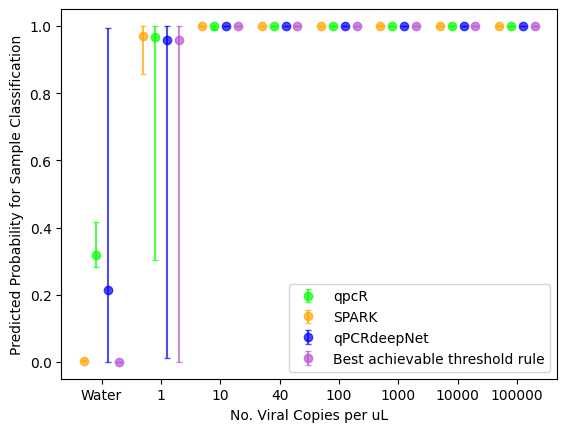

In [ ]:
bootstrap_mean = bootstrap_prob(test, n_bootstrap=1000)
xlabels = [str(x) for x in sorted(boxplot_df.dilution_level.unique())]
bootstrap_mean['x_numeric'] = bootstrap_mean.dilution_level.apply(lambda x: xlabels.index(str(x)))
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'qpcR'].x_numeric - 0.1, bootstrap_mean[bootstrap_mean.model == 'qpcR'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR', zorder=1)
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'SPARK'].x_numeric - 0.3, bootstrap_mean[bootstrap_mean.model == 'SPARK'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'SPARK'].lower, bootstrap_mean[bootstrap_mean.model == 'SPARK'].upper], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK', zorder=4)
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].lower, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].lower, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
plt.xticks(np.arange(0,8,1), labels=['Water'] + xlabels[1:])
plt.legend()
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability for Sample Classification')

In [ ]:
bootstrap_mean = bootstrap_prob(test, n_bootstrap=1000)

Text(0, 0.5, 'Predicted Probability for Sample Classification')

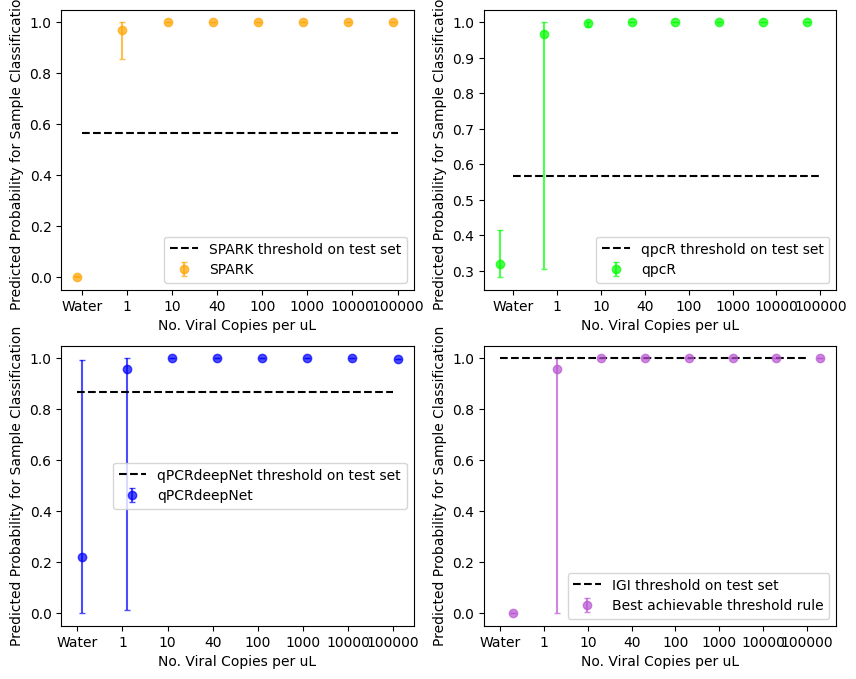

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

xlabels = [str(x) for x in sorted(boxplot_df.dilution_level.unique())]
bootstrap_mean['x_numeric'] = bootstrap_mean.dilution_level.apply(lambda x: xlabels.index(str(x)))
axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'SPARK'].x_numeric - 0.1, bootstrap_mean[bootstrap_mean.model == 'SPARK'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'SPARK'].lower, bootstrap_mean[bootstrap_mean.model == 'SPARK'].upper], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK')
# axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'qpcR'].x_numeric - 0.3, bootstrap_mean[bootstrap_mean.model == 'qpcR'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR')
# axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
# axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
axes[0,0].hlines(y=best_test_acc_thres, xmin=0, xmax=7, color='black', linestyle='dashed', label='SPARK threshold on test set')
axes[0,0].set_xticks(np.arange(0,8,1), labels=['Water'] + xlabels[1:])
axes[0,0].legend()
axes[0,0].set_xlabel('No. Viral Copies per uL')
axes[0,0].set_ylabel('Predicted Probability for Sample Classification')

axes[0,1].errorbar(bootstrap_mean[bootstrap_mean.model == 'qpcR'].x_numeric - 0.3, bootstrap_mean[bootstrap_mean.model == 'qpcR'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR')
# axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
# axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
axes[0,1].hlines(y=best_test_acc_thres, xmin=0, xmax=7, color='black', linestyle='dashed', label='qpcR threshold on test set')
axes[0,1].set_xticks(np.arange(0,8,1), labels=['Water'] + xlabels[1:])
axes[0,1].legend()
axes[0,1].set_xlabel('No. Viral Copies per uL')
axes[0,1].set_ylabel('Predicted Probability for Sample Classification')

axes[1,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].major_prob, 
             yerr=[bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].lower, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
# axes[0,0].errorbar(bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
axes[1,0].hlines(y=best_deepnet_test_acc_thres, xmin=0, xmax=7, color='black', linestyle='dashed', label='qPCRdeepNet threshold on test set')
axes[1,0].set_xticks(np.arange(0,8,1), labels=['Water'] + xlabels[1:])
axes[1,0].legend()
axes[1,0].set_xlabel('No. Viral Copies per uL')
axes[1,0].set_ylabel('Predicted Probability for Sample Classification')


axes[1,1].errorbar(bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].lower, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
axes[1,1].hlines(y=1., xmin=0, xmax=7, color='black', linestyle='dashed', label='IGI threshold on test set')
axes[1,1].set_xticks(np.arange(0,8,1), labels=['Water'] + xlabels[1:])
axes[1,1].legend()
axes[1,1].set_xlabel('No. Viral Copies per uL')
axes[1,1].set_ylabel('Predicted Probability for Sample Classification')


Text(0, 0.5, 'Predicted Probability for Sample Classification')

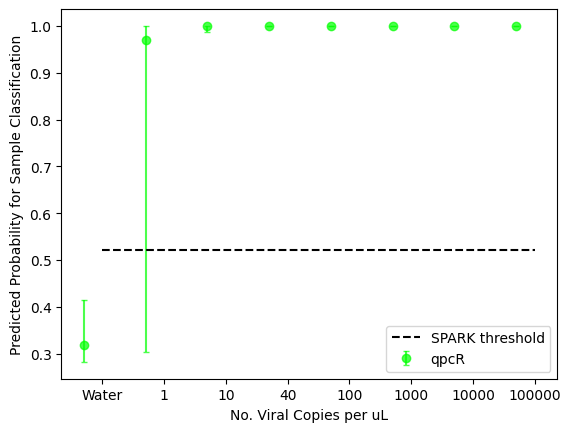

In [ ]:
bootstrap_mean = bootstrap_prob(test, n_bootstrap=1000)
xlabels = [str(x) for x in sorted(boxplot_df.dilution_level.unique())]
bootstrap_mean['x_numeric'] = bootstrap_mean.dilution_level.apply(lambda x: xlabels.index(str(x)))
# plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'SPARK'].x_numeric - 0.1, bootstrap_mean[bootstrap_mean.model == 'SPARK'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'SPARK'].lower, bootstrap_mean[bootstrap_mean.model == 'SPARK'].upper], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'qpcR'].x_numeric - 0.3, bootstrap_mean[bootstrap_mean.model == 'qpcR'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR')
# plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'qPCRdeepNet'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
# plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'Best achievable threshold rule'].major_prob, 
#             yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcR'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcR'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
plt.hlines(y=best_qpcr_test_acc_thres, xmin=0, xmax=7, color='black', linestyle='dashed', label='SPARK threshold')
plt.xticks(np.arange(0,8,1), labels=['Water'] + xlabels[1:])
plt.legend()
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability for Sample Classification')

### chip60 

([<matplotlib.axis.XTick at 0x7fadbffd4590>,
 [Text(0, 0, 'Water'),
  Text(1, 0, '1:$10^9$'),
  Text(2, 0, '1:$10^8$'),
  Text(3, 0, '1:$10^7$'),
  Text(4, 0, '1:$10^6$'),
  Text(5, 0, '1:$10^5$'),
  Text(6, 0, '1:$10^4$'),
  Text(7, 0, '1:$10^3$')])

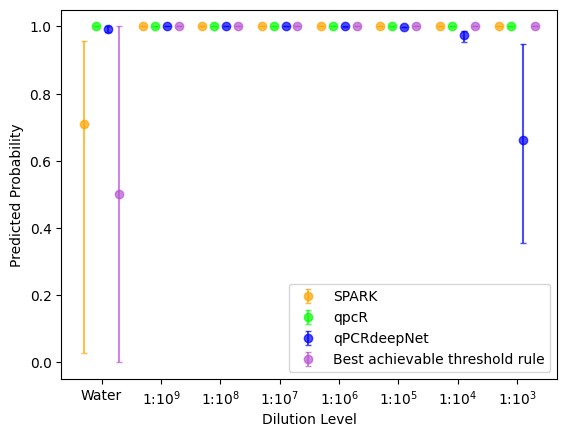

In [ ]:
n_bootstrap = 1000
bootstrap_df = pd.DataFrame()
# df = chip60_boxplot[chip60_boxplot['sample'] != 'Vim'].copy()
df = chip60_boxplot.copy()
for _ in range(n_bootstrap):
    sampled_wells = df[['dilution','curve_idx']].drop_duplicates().groupby(['dilution'], group_keys=False).apply(lambda x: x.curve_idx.sample(n=x.shape[0], replace=True)).reset_index()
    resample_df = df.merge(sampled_wells, on=['curve_idx'], how='right')
    # final_df = resample_df.groupby(['curve_idx','dilution','model','sample']).predicted_score.max().reset_index(name='major_prob')
    bootstrap_df = pd.concat([bootstrap_df, resample_df.rename(columns={'predicted_score':'major_prob'})], ignore_index=True)

bootstrap_mean = bootstrap_df.groupby(['dilution','model']).major_prob.mean().reset_index()
bootstrap_mean['lower'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution','model']).major_prob.apply(lambda x: (x.quantile(0.025))).reset_index(drop=True))
bootstrap_mean['upper'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution','model']).major_prob.apply(lambda x: (x.quantile(0.975))).reset_index(drop=True))

xlabels = [str(x) for x in sorted(chip60_boxplot.dilution.unique())]
bootstrap_mean['x_numeric'] = bootstrap_mean.dilution.apply(lambda x: xlabels.index(str(x)))
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'fusion'].x_numeric - 0.3, bootstrap_mean[bootstrap_mean.model == 'fusion'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'fusion'].lower, bootstrap_mean[bootstrap_mean.model == 'fusion'].upper], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'qpcr'].x_numeric - 0.1, bootstrap_mean[bootstrap_mean.model == 'qpcr'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcr'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcr'].upper], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'deepnet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'deepnet'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'deepnet'].lower, bootstrap_mean[bootstrap_mean.model == 'deepnet'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'igi'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'igi'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'igi'].lower, bootstrap_mean[bootstrap_mean.model == 'igi'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
plt.legend()
plt.xlabel('Dilution Level')
plt.ylabel('Predicted Probability')
plt.xticks(ticks=range(8),
           labels=['Water', r'1:$10^9$', r'1:$10^8$', r'1:$10^7$', r'1:$10^6$', r'1:$10^5$', r'1:$10^4$', r'1:$10^3$'])

([<matplotlib.axis.XTick at 0x7fadbff99550>,
 [Text(0, 0, 'Water'),
  Text(1, 0, '1:$10^9$'),
  Text(2, 0, '1:$10^8$'),
  Text(3, 0, '1:$10^7$'),
  Text(4, 0, '1:$10^6$'),
  Text(5, 0, '1:$10^5$'),
  Text(6, 0, '1:$10^4$'),
  Text(7, 0, '1:$10^3$')])

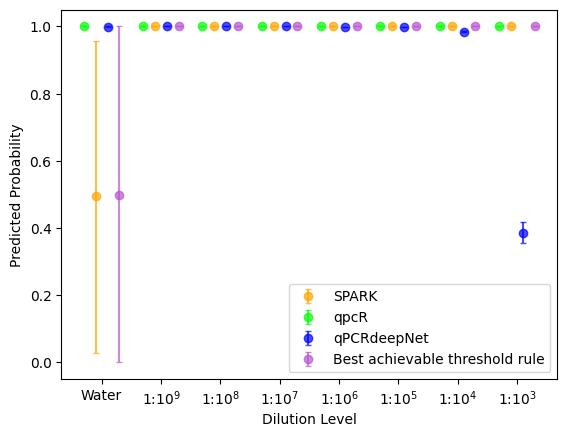

In [ ]:
n_bootstrap = 1000
bootstrap_df = pd.DataFrame()
df = chip60_boxplot[chip60_boxplot['sample'] == 'Vim'].copy()
for _ in range(n_bootstrap):
    sampled_wells = df[['dilution','curve_idx']].drop_duplicates().groupby(['dilution'], group_keys=False).apply(lambda x: x.curve_idx.sample(n=x.shape[0], replace=True)).reset_index()
    resample_df = df.merge(sampled_wells, on=['curve_idx'], how='right')
    # final_df = resample_df.groupby(['curve_idx','dilution','model','sample']).predicted_score.max().reset_index(name='major_prob')
    bootstrap_df = pd.concat([bootstrap_df, resample_df.rename(columns={'predicted_score':'major_prob'})], ignore_index=True)

bootstrap_mean = bootstrap_df.groupby(['dilution','model']).major_prob.mean().reset_index()
bootstrap_mean['lower'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution','model']).major_prob.apply(lambda x: (x.quantile(0.025))).reset_index(drop=True))
bootstrap_mean['upper'] = np.abs(bootstrap_mean.major_prob - bootstrap_df.groupby(['dilution','model']).major_prob.apply(lambda x: (x.quantile(0.975))).reset_index(drop=True))

xlabels = [str(x) for x in sorted(chip60_boxplot.dilution.unique())]
bootstrap_mean['x_numeric'] = bootstrap_mean.dilution.apply(lambda x: xlabels.index(str(x)))
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'fusion'].x_numeric - 0.1, bootstrap_mean[bootstrap_mean.model == 'fusion'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'fusion'].lower, bootstrap_mean[bootstrap_mean.model == 'fusion'].upper], fmt='o', color=test_color_map.get('SPARK'), alpha=0.7, capsize=2, label='SPARK')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'qpcr'].x_numeric - 0.3, bootstrap_mean[bootstrap_mean.model == 'qpcr'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'qpcr'].lower, bootstrap_mean[bootstrap_mean.model == 'qpcr'].upper], fmt='o', color=test_color_map.get('qpcR'), alpha=0.7, capsize=2, label='qpcR')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'deepnet'].x_numeric + 0.1, bootstrap_mean[bootstrap_mean.model == 'deepnet'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'deepnet'].lower, bootstrap_mean[bootstrap_mean.model == 'deepnet'].upper], fmt='o', color=test_color_map.get('qPCRdeepNet'), alpha=0.7, capsize=2, label='qPCRdeepNet')
plt.errorbar(bootstrap_mean[bootstrap_mean.model == 'igi'].x_numeric + 0.3, bootstrap_mean[bootstrap_mean.model == 'igi'].major_prob, 
            yerr=[bootstrap_mean[bootstrap_mean.model == 'igi'].lower, bootstrap_mean[bootstrap_mean.model == 'igi'].upper], fmt='o', color=test_color_map.get('Best achievable threshold rule'), alpha=0.7, capsize=2, label='Best achievable threshold rule')
plt.legend()
plt.xlabel('Dilution Level')
plt.ylabel('Predicted Probability')
plt.xticks(ticks=range(8),
           labels=['Water', r'1:$10^9$', r'1:$10^8$', r'1:$10^7$', r'1:$10^6$', r'1:$10^5$', r'1:$10^4$', r'1:$10^3$'])